## Fintech & Telecom Analytics: Customer Intelligence, Fraud Detection & Network Performance

#### Project Overview
This project simulates a real-world analytics engagement for a Nigerian financial services and
telecommunications company operating across five major regions — Lagos, Abuja, Port Harcourt,
Kano, and Ibadan. The analysis covers the full operational lifecycle of the business: from how
customers are acquired and retained, to how transactions flow, how fraud is detected, how support
teams perform, and how the network infrastructure holds up under load.

The goal is to surface actionable intelligence across five interconnected business domains using
a unified, multi-table data architecture — the kind that mirrors production analytics environments
in enterprise fintech and telecom organisations.

#### Business Problem

A fintech-telecom company is experiencing simultaneous pressure across multiple fronts:

- **Retention risk:** Churn is elevated among new and monthly-contract customers, threatening
  recurring revenue.
- **Fraud exposure:** Fraudulent transactions — though low in rate — are concentrated in specific
  regions and channels, with social engineering as the dominant attack vector.
- **Operational strain:** Customer support is overwhelmed, with SLA breach rates above 40% and
  an escalation rate that suggests systemic service delivery failure.
- **Infrastructure inequality:** Network performance varies dramatically by region, with northern
  cities experiencing latency and outage risk levels that directly degrade customer experience.
- **Financial visibility:** Transaction activity is geographically concentrated, with timing
  patterns that signal both opportunity and risk management gaps.

The business needs a cross-functional analytical layer that connects these five domains and
enables data-driven decision-making at the executive, operational, and product levels.

#### Datasets

This project integrates five datasets representing different operational layers of the business

1.**Dataset:**
Customer Master
**Description:**
Telecom subscriber records including tenure, contract type, payment method, services, and churn status 
**Volume:** 
7,043 customers

2.**Dataset:**
Transaction Log
**Description:**
Financial transaction records including amount, channel, region, time, and status **Volume:** 
113,051 transactions

3.**Dataset:**
Fraud Log
**Description:**
Fraud detection records with risk scores, techniques, merchant categories, and composite risk indicators **Volume:** 
1,000,000 records

4.**Dataset:**
Customer Support Tickets 
**Description:**
Support ticket records including category, priority, resolution time, SLA status, and satisfaction scores **Volume:** 
160,013 tickets

5.**Dataset:**
Network Performance 
**Description:**
Tower-level network telemetry including latency, download/upload speed, congestion, signal strength, and outage flags **Volume:** 
Real-time session records

**Note on synthetic data:** Several columns were generated synthetically to enrich datasets for analytical depth — including regional tags, outage flags, network type distributions, and device/merchant identifiers. All synthetic generation was probability-weighted to reflect realistic Nigerian fintech and telecom operating conditions. 

#### Analytical Objectives

This project answers the following business questions across five analytical domains:

**Customer & Retention Intelligence**
- What is the true churn risk profile of the customer base?
- Which customer segments — by contract, tenure, revenue, and CLV — are most at risk?
- What is the projected customer lifetime value of the active portfolio?

**Financial & Transaction Performance**
- Where and when is transaction activity most concentrated?
- What is the distribution of transaction value across regions and channels?
- Who are the highest-value customers, and what are their behavioural patterns?

**Fraud Intelligence & Risk Operations**
- What is the fraud rate, and how is it distributed across regions, channels, and merchant categories?
- Which fraud techniques are most prevalent, and where are high-velocity attack clusters forming?
- What composite risk indicators most reliably predict fraudulent activity?

**Customer Support & Service Delivery**
- Is the support organisation meeting SLA commitments across ticket priorities?
- What issue categories drive the highest escalation and resolution delay?
- Which customer segments are most frustrated, and what is their churn risk profile?

**Network Infrastructure & Performance**
- How does network quality — latency, speed, congestion, outage risk — vary across regions?
- What environmental and load factors correlate with performance degradation?
- Which towers and regions are most critical to infrastructure investment planning?

#### Methodology

The analysis follows a structured, five-stage analytical pipeline:

1. **Data Cleaning** — Loading datasets, type casting, handling nulls, and
   standardising column naming conventions.
2. **Data Quality Engineering** — IQR-based outlier detection, referential integrity checks,
   logical consistency validation, and temporal consistency resolution.
3. **Feature Engineering** — Creation of 40+ derived business features including CLV segments,
   churn risk flags, fraud pressure scores, frustration indices, network stability scores, and
   escalation tiers.
4. **KPI Engineering & EDA** — Domain-specific KPI computation and exploratory visualisation
   across all five datasets.
5. **Cross-Dataset Analysis** — Relational joins across domains to surface multi-dimensional
   business intelligence (e.g., churn risk × fraud exposure, network quality × support pressure).

#### Tools & Technologies

- **Python** — pandas, NumPy, Matplotlib, Seaborn
- **Tableau Public** — Interactive dashboard layer (5 dashboards)
- **Data Sources** — YBI Foundation (Telecom Churn), Kaggle (Customer Support, Network,
  Fraud Log), synthetically enriched

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
import io
import requests
import zipfile

## Loading Datasets and Data cleaning

In [2]:
#1. Assign and read Customer Master Dataset as csv file
url = 'https://raw.githubusercontent.com/Esters-10/fintech-telecom-analytics/refs/heads/main/TelecomCustomerChurn.csv'
response = requests.get(url)

In [3]:
customer = pd.read_csv(io.StringIO(response.text))

In [4]:
customer.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [5]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   Gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
customer.shape

(7043, 21)

In [7]:
#Data cleaning

##Change dtype from string to float
customer['TotalCharges'] = pd.to_numeric(customer['TotalCharges'], errors= 'coerce')
customer['TotalCharges'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [8]:
customer['TotalCharges'].dtype

dtype('float64')

In [9]:
##Change data value to binary form
customer['Churn'] = customer['Churn'].map({
    'Yes': 1,
    'No': 0,
})

In [10]:
customer['Churn'].shape
customer['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [11]:
print(customer['Churn'].isnull().sum())

0


In [12]:
##Change data value from binary to categorical value
customer['SeniorCitizen'] = customer['SeniorCitizen'].map({
    0: 'Non-Senior',
    1: 'Senior'
})
customer['SeniorCitizen'].value_counts()

SeniorCitizen
Non-Senior    5901
Senior        1142
Name: count, dtype: int64

In [13]:
#Change CustomerId to customer_id in customer table
customer = customer.rename(columns={
    'customerID': 'customer_id'
})

In [14]:
#Change customer_id format in customer table
customer['customer_id'] = [
    f'Cust_{i:05d}'
    for i in range(1, len(customer)+1)
]

In [15]:
#2. Assign and read Customer Support Dataset as csv file
url = "https://raw.githubusercontent.com/Esters-10/fintech-telecom-analytics/main/customer_support_tickets_200k%202.csv.zip"
response = requests.get(url)

In [16]:
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files inside zip:", z.namelist())

    with z.open(z.namelist()[0]) as f:
        customer_support = pd.read_csv(f)

Files inside zip: ['customer_support_tickets_200k 2.csv', '__MACOSX/._customer_support_tickets_200k 2.csv']


In [17]:
customer_support.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [18]:
customer_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  str    
 2   customer_email               200000 non-null  str    
 3   product                      200000 non-null  str    
 4   category                     200000 non-null  str    
 5   issue_description            200000 non-null  str    
 6   resolution_notes             200000 non-null  str    
 7   priority                     200000 non-null  str    
 8   status                       200000 non-null  str    
 9   channel                      200000 non-null  str    
 10  region                       200000 non-null  str    
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  str    
 13  subscripti

In [19]:
#Remove irrelevant columns
## customer_support = customer_support.drop(columns=[
##   'customer_name',
##    'customer_email', 
##    'issue_description',
##    'resolution_notes',
##    'browser',
##    'operating_system',
##])

In [20]:
#Remove irrelevant columns
##customer_support = customer_support.drop(columns=[
##    'preferred_contact_time',
##    'language',
##    'payment_method',
##    'subscription_type'
##])

In [21]:
customer_support['category'].value_counts()

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

In [22]:
#Generate random customer_id synthetically from customer dataset
customer_support['customer_id'] = np.random.choice(
    customer['customer_id'],
    size= len(customer_support)
)

In [23]:
#Re-shape Priority volume distribution
priority_vol = {"Low": 1.60, "Medium": 1.20, "High": 0.35, "Urgent": 0.15}

customer_support = customer_support.sample(
    frac = 1.0,
    replace = True,
    weights = customer_support['priority'].map(priority_vol).fillna(1.0),
).reset_index(drop = True)

In [24]:
#Re-shape Region volume distribution
region_vol = {"Lagos": 1.85, "Abuja": 1.15, "Port Harcourt": 0.85, "Ibadan": 0.55, "Kano": 0.35}

customer_support = customer_support.sample(
    frac = 1.0,
    replace = True,
    weights = customer_support['region'].map(region_vol).fillna(1.0),
).reset_index(drop = True)

In [25]:
#Re-shape Categorry Ticket distribution
category_ticket_vol = {"Login Issue": 1.75, "Feature Request": 0.80, "Subscription Cancellation": 0.35, "Security Concern": 0.1, 
                       "Performance Issue": 0.65, "Refund Request": 0.95, "Data Sync Issue": 0.5, "Bug Report": 1.2, 
                       "Payment Problem": 1.5, "Account Suspension": 0.2}

customer_support = customer_support.sample(
    frac = 1.0,
    replace = True,
    weights = customer_support['category'].map(category_ticket_vol).fillna(1.0),
).reset_index(drop = True)

In [26]:
##Create RW Resolution time with respect to priority
noise_hrs = np.random.uniform(-1.5, 1.5, len(customer_support))
#Define multipliers
priority_resolution_offsets = {
    "Urgent": 0.03,
    "High": 0.15,
    "Medium": 0.50,
    "Low": 1.20
}
#Create RW_resolution time
customer_support["resolution_time_hours"] = (
    customer_support["resolution_time_hours"]
    * (customer_support["priority"].map(priority_resolution_offsets).fillna(1.0).astype(float))
) + noise_hrs
#Modify Unrealistic values
customer_support["resolution_time_hours"] = (
    customer_support["resolution_time_hours"]
    .clip(lower=0.5)
    .round(1)
)

In [27]:
##Create RW first response time with respect to priority
priority_response_offsets = {
    "Urgent": 0.05,
    "High": 0.12,
    "Medium": 0.25,
    "Low": 0.40
}

customer_support["first_response_time_hours"] = (
    customer_support["resolution_time_hours"] * (customer_support["priority"].map(priority_response_offsets).fillna(0.20).astype(float))
).round(1)

In [28]:
##Create RW CSAT score with respect to tenure
customer_support["customer_satisfaction_score"] = customer_support.apply(
    lambda row: (
        row["customer_satisfaction_score"] * 0.70 if row["customer_tenure_months"] <= 12
        else row["customer_satisfaction_score"] * 1.05 if row["customer_tenure_months"] <= 36
        else row["customer_satisfaction_score"] * 1.45
    ),
    axis=1,
)
# Lock the scores securely within standard customer satisfaction limits (1.0 to 5.0 stars)
customer_support["customer_satisfaction_score"] = customer_support["customer_satisfaction_score"].clip(1.0, 5.0).round(1)

In [29]:
customer_support['sla_breached'].value_counts()

sla_breached
Yes    100477
No      99523
Name: count, dtype: int64

In [30]:
#re-arrange column heading
cols = ['ticket_id', 'customer_id'] + [col for col in customer_support.columns if col not in ['ticket_id', 'customer_id']]

customer_support = customer_support[cols]

In [31]:
#Convert "date" to date_time
customer_support['ticket_created_date'] = pd.to_datetime(customer_support['ticket_created_date'])
customer_support['ticket_resolved_date'] = pd.to_datetime(customer_support['ticket_resolved_date'])

In [32]:
#3. Assign and read Telecom Network Dataset as csv file
url = "https://raw.githubusercontent.com/Esters-10/fintech-telecom-analytics/refs/heads/main/Telecom_Network_Data.csv"
response = requests.get(url)

In [33]:
#3. Assign and read Telecom Network Dataset as csv file
network = pd.read_csv(io.StringIO(response.text))

In [34]:
network.head()

,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
0,2025-01-01 00:00:00,1,152,80.671584,9.988305,158.141290,Clear,0
1,2025-01-01 01:00:00,1,171,19.819479,3.846097,174.573468,Clear,0
2,2025-01-01 02:00:00,1,713,66.834405,3.764167,147.179767,Snow,0
3,2025-01-01 03:00:00,1,435,22.273372,9.986821,67.806026,Clear,0
4,2025-01-01 04:00:00,1,797,7.190930,26.713958,85.973585,Clear,0


In [35]:
network.info()

<class 'pandas.DataFrame'>
RangeIndex: 3605 entries, 0 to 3604
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        3605 non-null   str    
 1   tower_id         3605 non-null   int64  
 2   users_connected  3605 non-null   int64  
 3   download_speed   3605 non-null   float64
 4   upload_speed     3605 non-null   float64
 5   latency          3605 non-null   float64
 6   weather          3605 non-null   str    
 7   congestion       3605 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 225.4 KB


In [36]:
#Data cleaning
network['timestamp']= pd.to_datetime(network['timestamp'])

In [37]:
#Expand dataset synthetically 

##Network_type
network['network_type']= np.random.choice(
    ['3G', '4G', '5G'],
    size= len(network),
    p= [0.2, 0.6, 0.2]
)

##Signal_strength
network['signal_strength']= np.random.randint(
    40, 100,
    size=len(network)
)

##Failed_requests
network['failed_requests']= np.random.poisson(
    3,
    size= len(network)
)

##Region
network['region']= np.random.choice(
    ['Lagos', 'Abuja', 'Port Harcourt', 'Kano', 'Ibadan'],
    size= len(network)
)

##Session_id
network['session_id']= [
    f"SESS_{i:06d}"
    for i in range(1, len(network)+1)
]


In [38]:
#Generate organic noise to simulate real world situation 
np.random.seed(42)
noise_speed= np.random.uniform(-2.5, 2.5, len(network))
noise_latency = np.random.uniform(-3.0, 3.0, len(network))

##Consider regional difference
download_offsets = {
    "Lagos": 32.5,
    "Abuja": 14.8,
    "Port Harcourt": -5.2,
    "Ibadan": -18.4,
    "Kano": -27.1
}
##rw_download_speed
network['rw_download_speed'] = (
    network["download_speed"] + network["region"].map(download_offsets).fillna(0.0) + noise_speed)
network["rw_download_speed"] = network["rw_download_speed"].clip(lower=4.5).round(1)

In [39]:
##Real-World Upload Speed
##Consider regional difference
upload_offsets = {
    "Lagos": 15.5,
    "Abuja": 8.2,
    "Port Harcourt": -2.4,
    "Ibadan": -6.1,
    "Kano": -11.8
}
##rw_upload_speed
network["rw_upload_speed"] = (
    network["upload_speed"] + network["region"].map(upload_offsets).fillna(0.0) + (noise_speed * 0.5))
network["rw_upload_speed"] = network["rw_upload_speed"].clip(lower=1.5).round(1)

In [40]:
##Real-World Latency Delay
##Consider regional difference
latency_offsets = {
    "Lagos": -72.5,
    "Abuja": -55.4,
    "Port Harcourt": -15.2,
    "Ibadan": 24.8,
    "Kano": 48.1
}
##rw_latency
network["rw_latency"] = (
    network["latency"] + network["region"].map(latency_offsets).fillna(0.0) + noise_latency
)
#Minimum latency value should be 12ms (speed of light)
network["rw_latency"] = network["rw_latency"].clip(lower=12.0).round(0)

In [41]:
##Real-World Failed Connection Request 
failed_multipliers = {
    "Kano": 3,
    "Ibadan": 2,
    "Port Harcourt": 1.5,
    "Abuja": 1,
    "Lagos": 1
}
##rw_failed_request
network["rw_failed_request"] = network.apply(lambda row: min(10.0, max(0.0, row["failed_requests"]
            * failed_multipliers.get(row["region"], 1),
        ),
    ), axis=1,).round(0)

In [42]:
network.head()

,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion,network_type,signal_strength,failed_requests,region,session_id,rw_download_speed,rw_upload_speed,rw_latency,rw_failed_request
0,2025-01-01 00:00:00,1,152,80.671584,9.988305,158.141290,Clear,0,4G,93,3,Ibadan,SESS_000001,61.6,3.6,181.0,6.0
1,2025-01-01 01:00:00,1,171,19.819479,3.846097,174.573468,Clear,0,4G,86,4,Port Harcourt,SESS_000002,16.9,2.6,161.0,6.0
2,2025-01-01 02:00:00,1,713,66.834405,3.764167,147.179767,Snow,0,3G,66,1,Ibadan,SESS_000003,49.6,1.5,171.0,2.0
3,2025-01-01 03:00:00,1,435,22.273372,9.986821,67.806026,Clear,0,4G,84,2,Port Harcourt,SESS_000004,17.6,7.8,55.0,3.0
4,2025-01-01 04:00:00,1,797,7.190930,26.713958,85.973585,Clear,0,3G,54,3,Lagos,SESS_000005,38.0,41.4,16.0,3.0


In [43]:
##Drop Synthetic Columns
network = network.drop(columns=[
    'download_speed',
    'upload_speed',
    'latency',
    'failed_requests'
])                   

In [44]:
##Update RW colummn name to normal
network.rename(columns={
    "rw_download_speed": "download_speed",
    "rw_upload_speed": "upload_speed",
    "rw_latency": "latency",
    "rw_failed_request": "failed_requests"
}, inplace=True)

In [45]:
network.head()

,timestamp,tower_id,users_connected,weather,congestion,network_type,signal_strength,region,session_id,download_speed,upload_speed,latency,failed_requests
0,2025-01-01 00:00:00,1,152,Clear,0,4G,93,Ibadan,SESS_000001,61.6,3.6,181.0,6.0
1,2025-01-01 01:00:00,1,171,Clear,0,4G,86,Port Harcourt,SESS_000002,16.9,2.6,161.0,6.0
2,2025-01-01 02:00:00,1,713,Snow,0,3G,66,Ibadan,SESS_000003,49.6,1.5,171.0,2.0
3,2025-01-01 03:00:00,1,435,Clear,0,4G,84,Port Harcourt,SESS_000004,17.6,7.8,55.0,3.0
4,2025-01-01 04:00:00,1,797,Clear,0,3G,54,Lagos,SESS_000005,38.0,41.4,16.0,3.0


In [46]:
#4. Assign and read Fraud Log Dataset as csv file
url = "https://raw.githubusercontent.com/Esters-10/fintech-telecom-analytics/main/nibss_fraud_dataset_update_3.csv.gz"
response = requests.get(url)

In [47]:
fraud_log = pd.read_csv(io.BytesIO(response.content), compression = "gzip")

In [48]:
fraud_log.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   timestamp            1000000 non-null  str    
 1   amount               1000000 non-null  float64
 2   channel              1000000 non-null  str    
 3   merchant_category    1000000 non-null  str    
 4   location             1000000 non-null  str    
 5   age_group            1000000 non-null  str    
 6   is_fraud             1000000 non-null  int64  
 7   fraud_technique      3000 non-null     str    
 8   velocity_score       1000000 non-null  float64
 9   merchant_risk_score  1000000 non-null  float64
 10  composite_risk       1000000 non-null  float64
dtypes: float64(4), int64(1), str(6)
memory usage: 83.9 MB


In [49]:
#Data cleaning
fraud_log['timestamp']= pd.to_datetime(fraud_log['timestamp'])

/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_41033/2094322595.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  fraud_log['timestamp']= pd.to_datetime(fraud_log['timestamp'])


In [50]:
fraud_log.head()

,timestamp,amount,channel,merchant_category,location,age_group,is_fraud,fraud_technique,velocity_score,merchant_risk_score,composite_risk
0,2023-01-14 04:31:00,32266.83,Mobile,Grocery,Other,30-39,0,NaN,0.189369,0.215000,0.070560
1,2023-01-17 11:20:00,72530.49,Web,Entertainment,Other,30-39,0,NaN,0.425671,0.877424,0.276849
2,2023-01-22 02:17:00,168152.87,Mobile,Transport,Other,30-39,0,NaN,0.986866,0.440230,0.163649
3,2023-01-24 08:18:00,16439.93,Mobile,Entertainment,Other,30-39,0,NaN,0.096484,0.877424,0.266315
4,2023-02-01 15:39:00,9922.68,POS,Education,Other,30-39,0,NaN,0.058235,0.231291,0.071251


In [51]:
#change location column to region in fraud_log dataset.
fraud_log.rename(
    columns={"location": "region"},
    inplace= True)


In [52]:
fraud_log['customer_id']= np.random.choice(
    customer['customer_id'],
    size= len(fraud_log)
)

In [53]:
fraud_log['transaction_id'] = [
    f'TXN_{i:07d}'
    for i in range(1, len(fraud_log)+1)
]

In [54]:
fraud_log.columns

Index(['timestamp', 'amount', 'channel', 'merchant_category', 'region',
       'age_group', 'is_fraud', 'fraud_technique', 'velocity_score',
       'merchant_risk_score', 'composite_risk', 'customer_id',
       'transaction_id'],
      dtype='str')

In [55]:
fraud_log['fraud_technique'].value_counts()

fraud_technique
SOCIAL_ENGINEERING    1929
ROBBERY                341
CARD_THEFT             220
OTHER                  220
PIN_COMPROMISE         158
PHISHING               132
Name: count, dtype: int64

In [56]:
#Fill na with 'No Fraud
fraud_log['fraud_technique']= fraud_log['fraud_technique'].fillna('No Fraud')

In [57]:
#5. Derived Transaction Dataset from Fraud_log 
##Create transaction dataset from fraud_log dataset
transactions = fraud_log[
    [
        'transaction_id',
        'customer_id',
        'timestamp',
        'amount',
        'channel',
        'region'
    ]].copy()

In [58]:
#Assign timestamp to transaction_time
transactions['transaction_time'] = transactions['timestamp']

In [59]:
#Derive date from transaction_time
transactions['date'] = transactions['transaction_time'].dt.date

In [60]:
#Change 'date' d_type to datetime
transactions['date'] = pd.to_datetime(transactions['date'])

In [61]:
#Remove timestamp
transactions = transactions.drop(columns= 'timestamp')

In [62]:
#Synthetic Columns Generation
##transaction_status
transactions['transaction_status'] = np.random.choice(
    ['Successful', 'Failed', 'Pending'],
    size= len(transactions),
    p= [0.92, 0.05, 0.03]
)
device_pool = [
    f'DEV_{i:05d}'
    for i in range(1, 20001)
]

##device_id
transactions['device_id'] = np.random.choice(
    device_pool,
    size= len(transactions)
)

##merchant_id
merchant_pool = [
    f'MERCH{i:04d}'
    for i in range(1, 501)
]

transactions['merchant_id'] = np.random.choice(
    merchant_pool,
    size= len(transactions)
)

##transaction['type']
transactions['type'] = np.random.choice(
    ['Credit', 'Transfer', 'Debit'],
    size= len(transactions),
    p= [0.4, 0.3, 0.3]
)

In [63]:
#Re-arrange transaction column
cols = ['transaction_id', 'customer_id', 'transaction_time', 'date', 'type'] + [col for col in transactions.columns if col not in [
    'transaction_id', 'customer_id', 'transaction_time', 'date', 'type']]
transactions = transactions[cols]

In [64]:
#Change transaction_id to a unique key
transactions['transaction_id'] = [
    f'TXN_{i:07d}'
    for i in range(1, len(transactions)+1)
]

In [65]:
transactions.head()

,transaction_id,customer_id,transaction_time,date,type,amount,channel,region,transaction_status,device_id,merchant_id
0,TXN_0000001,Cust_03544,2023-01-14 04:31:00,2023-01-14,Transfer,32266.83,Mobile,Other,Successful,DEV_13730,MERCH0189
1,TXN_0000002,Cust_05602,2023-01-17 11:20:00,2023-01-17,Transfer,72530.49,Web,Other,Successful,DEV_16695,MERCH0274
2,TXN_0000003,Cust_06137,2023-01-22 02:17:00,2023-01-22,Transfer,168152.87,Mobile,Other,Successful,DEV_09031,MERCH0177
3,TXN_0000004,Cust_05143,2023-01-24 08:18:00,2023-01-24,Credit,16439.93,Mobile,Other,Successful,DEV_02288,MERCH0113
4,TXN_0000005,Cust_00296,2023-02-01 15:39:00,2023-02-01,Debit,9922.68,POS,Other,Successful,DEV_05288,MERCH0430


In [66]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   transaction_id      1000000 non-null  str           
 1   customer_id         1000000 non-null  str           
 2   transaction_time    1000000 non-null  datetime64[us]
 3   date                1000000 non-null  datetime64[s] 
 4   type                1000000 non-null  str           
 5   amount              1000000 non-null  float64       
 6   channel             1000000 non-null  str           
 7   region              1000000 non-null  str           
 8   transaction_status  1000000 non-null  str           
 9   device_id           1000000 non-null  str           
 10  merchant_id         1000000 non-null  str           
dtypes: datetime64[s](1), datetime64[us](1), float64(1), str(8)
memory usage: 83.9 MB


## Data Quality Engineering

In [67]:
#Create a function to standardize columns
def clean_columns(df):
    df.columns= (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )
    return df  

In [68]:
customer = clean_columns(customer)
transactions = clean_columns(transactions)
customer_support = clean_columns(customer_support)
network = clean_columns(network)
fraud_log = clean_columns(fraud_log)

In [69]:
#Data type validation
customer.info()
transactions.info()
customer_support.info()
network.info()
fraud_log.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   str    
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [70]:
#Change invalid customer data type
customer['churn'] = customer['churn'].astype('category')
customer['seniorcitizen'] = customer['seniorcitizen'].astype('category')

In [71]:
##Change currency value to Naira
customer['totalcharges'] = customer['totalcharges'].fillna(customer['totalcharges'].mean())
customer['totalcharges'] = customer['totalcharges'] * 1200
customer['monthlycharges'] = customer['monthlycharges'] * 1200

In [72]:
#Change invalid transaction data type
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['transaction_id'] = transactions['transaction_id'].astype('str')

In [73]:
#Change invalid customer_support data type
col_to_fix = ['priority', 'status', 'channel', 'escalated', 'sla_breached', 'customer_segment']

customer_support[col_to_fix] = customer_support[col_to_fix].astype('category')

In [74]:
#Change invalid network data type
cols_to_fix = ['weather', 'network_type', 'region']

network[cols_to_fix] = network[cols_to_fix].astype('category')

In [75]:
#Change invalid fraud_log data type
cols_to_fix = ['is_fraud', 'channel', 'merchant_category', 'region', 'age_group', 'fraud_technique']
fraud_log[cols_to_fix] = fraud_log[cols_to_fix].astype('category')

In [76]:
#Change invalid transactions data type
cols_to_fix = ['type', 'region', 'transaction_status']
transactions[cols_to_fix] = transactions[cols_to_fix].astype('category')

In [77]:
#Check duplicate values in primary keys 
customer.duplicated().sum()
transactions.duplicated().sum()
customer_support.duplicated().sum()
network.duplicated().sum()

np.int64(0)

In [78]:
customer['customer_id'].duplicated().sum()

np.int64(0)

In [79]:
transactions['transaction_id'].duplicated().sum()

np.int64(0)

In [80]:
customer_support['ticket_id'].duplicated().sum()

np.int64(140801)

In [81]:
network['session_id'].duplicated().sum()

np.int64(0)

In [82]:
fraud_log['transaction_id'].duplicated().sum()

np.int64(0)

In [83]:
##Primary Key Uniqueness
customer['customer_id'].is_unique
transactions['transaction_id'].is_unique
customer_support['ticket_id'].is_unique
network['session_id'].is_unique
fraud_log['transaction_id'].is_unique

True

## Outlier Detection Using IQR
#### perform outlier detection on key numerical columns because extreme values can represent either data errors or meaningful business events. Identifying these helps improve data quality, model accuracy, and business insights.

In [84]:
#Transaction Dataset
## WHY?
## Detect possible fraudulent transactions
## Identify unusually high-value spending
## Flag system or data entry errors

Q1 = transactions['amount'].quantile(0.25)
Q3 = transactions['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

trans_outliers = transactions[
    (transactions['amount'] < lower_limit) |
    (transactions['amount'] > upper_limit)
    ]

trans_outliers.info()

<class 'pandas.DataFrame'>
Index: 98592 entries, 39 to 999988
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      98592 non-null  str           
 1   customer_id         98592 non-null  str           
 2   transaction_time    98592 non-null  datetime64[us]
 3   date                98592 non-null  datetime64[s] 
 4   type                98592 non-null  category      
 5   amount              98592 non-null  float64       
 6   channel             98592 non-null  str           
 7   region              98592 non-null  category      
 8   transaction_status  98592 non-null  category      
 9   device_id           98592 non-null  str           
 10  merchant_id         98592 non-null  str           
dtypes: category(3), datetime64[s](1), datetime64[us](1), float64(1), str(5)
memory usage: 7.1 MB


In [85]:
#Fraud_log Dataset ('composite_risk') Outlier Detection
## WHY?
## Detect high-risk or suspicious transactions
## Help prioritize fraud investigations
## Identify potential fraud clusters or attacks

Q1 = fraud_log['composite_risk'].quantile(0.25)
Q3 = fraud_log['composite_risk'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

composite_risk_outliers = fraud_log[
    (fraud_log['composite_risk'] < lower_limit) |
    (fraud_log['composite_risk'] > upper_limit) 
    ]
composite_risk_outliers.info()

<class 'pandas.DataFrame'>
Index: 17370 entries, 62 to 999885
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            17370 non-null  datetime64[us]
 1   amount               17370 non-null  float64       
 2   channel              17370 non-null  category      
 3   merchant_category    17370 non-null  category      
 4   region               17370 non-null  category      
 5   age_group            17370 non-null  category      
 6   is_fraud             17370 non-null  category      
 7   fraud_technique      17370 non-null  category      
 8   velocity_score       17370 non-null  float64       
 9   merchant_risk_score  17370 non-null  float64       
 10  composite_risk       17370 non-null  float64       
 11  customer_id          17370 non-null  str           
 12  transaction_id       17370 non-null  str           
dtypes: category(6), datetime64[us](1), float64(4)

In [86]:
composite_risk_outliers.head()

,timestamp,amount,channel,merchant_category,region,age_group,is_fraud,fraud_technique,velocity_score,merchant_risk_score,composite_risk,customer_id,transaction_id
62,2023-08-10 13:09:00,715260.02,Mobile,Bill_Payment,Other,30-39,0,No Fraud,8.508099,0.829641,0.391841,Cust_04612,TXN_0000063
71,2023-09-04 09:52:00,811915.24,IB,Entertainment,Other,30-39,0,No Fraud,9.736463,0.877424,0.425651,Cust_00187,TXN_0000072
92,2023-11-24 09:15:00,3313854.66,Mobile,Transport,Other,30-39,0,No Fraud,19.448546,0.440230,0.470966,Cust_05807,TXN_0000093
175,2023-10-03 17:08:00,1879843.00,Web,Fashion,Other,40+,0,No Fraud,10.147098,0.542436,0.483025,Cust_03220,TXN_0000176
263,2023-07-04 17:33:00,1149760.20,IB,Entertainment,Lagos,30-39,0,No Fraud,6.576358,0.877424,0.473671,Cust_06077,TXN_0000264


In [87]:
#Network Dataset('latency') Outlier Detection
## WHY?
## Identify network congestion or outages
## Detect poor service performance in regions or towers
## Help monitor infrastructure instability

Q1 = network['latency'].quantile(0.25)
Q3 = network['latency'].quantile(0.75)

IQR = Q3 - Q1 

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

latency_outliers = network[
    (network['latency'] < lower_limit) |
    (network['latency'] > upper_limit)
    ]

latency_outliers.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        0 non-null      datetime64[us]
 1   tower_id         0 non-null      int64         
 2   users_connected  0 non-null      int64         
 3   weather          0 non-null      category      
 4   congestion       0 non-null      int64         
 5   network_type     0 non-null      category      
 6   signal_strength  0 non-null      int64         
 7   region           0 non-null      category      
 8   session_id       0 non-null      str           
 9   download_speed   0 non-null      float64       
 10  upload_speed     0 non-null      float64       
 11  latency          0 non-null      float64       
 12  failed_requests  0 non-null      float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(4), str(1)
memory usage: 228.0 bytes


In [88]:
#Customer_support Dataset('resolution_time_hours') Outlier Detection
## WHY?
## Detect delayed ticket resolutions
## Highlight SLA breaches
## Identify inefficient support processes or complex cases

Q1 = customer_support['resolution_time_hours'].quantile(0.25)
Q3 = customer_support['resolution_time_hours'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR 

rth_outliers = customer_support[
    (customer_support['resolution_time_hours'] < lower_limit) |
    (customer_support['resolution_time_hours'] > upper_limit)
    ]

rth_outliers.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    0 non-null      int64         
 1   customer_id                  0 non-null      str           
 2   customer_name                0 non-null      str           
 3   customer_email               0 non-null      str           
 4   product                      0 non-null      str           
 5   category                     0 non-null      str           
 6   issue_description            0 non-null      str           
 7   resolution_notes             0 non-null      str           
 8   priority                     0 non-null      category      
 9   status                       0 non-null      category      
 10  channel                      0 non-null      category      
 11  region                       0 non-null      str           
 12  cus

## Data Consistency(Relationship) Validation 

#### Questions like:
#### 1. Do all transaction customer_ids exist in customers?
#### 2. Are fraud transactions linked to valid customers?
#### 3. Do all customer support tickets belong to real customers?
#### need to be answered.

In [89]:
##1. Do all transaction customer_ids exist in customers?
transactions['customer_id'].isin(
    customer['customer_id']).all()

np.True_

In [90]:
##2. Are fraud transactions linked to valid customers?
fraud_log['customer_id'].isin(
    customer['customer_id']).all()

np.True_

In [91]:
##3. Do all customer support tickets belong to real customers?
customer_support['customer_id'].isin(
    customer['customer_id']).all()

np.True_

In [92]:
## Logical Consistency Check
#1.Transaction logic
(transactions['amount'] < 0).sum()

np.int64(0)

In [93]:
#2. Customer Support Timing Logic
(customer_support['resolution_time_hours'] <= customer_support['first_response_time_hours']).sum()

np.int64(0)

In [94]:
#3. Network Logic
(network['download_speed'] <= 0).sum()
(network['upload_speed'] <= 0).sum()
(network['latency'] <= 0).sum()

np.int64(0)

In [95]:
## Temporal Consistency
#1. Transaction Time Validity
transactions['date'].notnull().all()

np.True_

In [96]:
print("Missing dates:", transactions['date'].isnull().sum())

Missing dates: 0


In [97]:
#2. Support Ticket Timeline
(customer_support['ticket_resolved_date'] <= customer_support['ticket_created_date']).sum()

np.int64(13071)

In [98]:
#Change data type to datetime
customer_support['ticket_created_date'] = pd.to_datetime(customer_support['ticket_created_date'])
customer_support['ticket_resolved_date'] = pd.to_datetime(customer_support['ticket_resolved_date'])

In [99]:
#Resolve issue by swapping values
## 1. Identify the 'broken' rows where Created is AFTER Resolved
mask = customer_support['ticket_created_date'] > customer_support['ticket_resolved_date']

## 2. Swap values using .values to force the data to move between columns
customer_support.loc[mask, ['ticket_created_date', 'ticket_resolved_date']] = \
    customer_support.loc[mask, ['ticket_resolved_date', 'ticket_created_date']].values


In [100]:
## 3. Final Check (Should be 0)
print((customer_support['ticket_resolved_date'] < customer_support['ticket_created_date']).sum())

0


In [101]:
#4. Check Category Consistency
#a. transaction_channel
transactions['channel'].value_counts()

channel
Mobile    449522
Web       200488
POS       180035
IB         99653
ECOM       50227
ATM        20075
Name: count, dtype: int64

In [102]:
fraud_log.columns

Index(['timestamp', 'amount', 'channel', 'merchant_category', 'region',
       'age_group', 'is_fraud', 'fraud_technique', 'velocity_score',
       'merchant_risk_score', 'composite_risk', 'customer_id',
       'transaction_id'],
      dtype='str')

In [103]:
fraud_log['channel'].value_counts()

channel
Mobile    449522
Web       200488
POS       180035
IB         99653
ECOM       50227
ATM        20075
Name: count, dtype: int64

In [104]:
fraud_log['is_fraud'].value_counts()

is_fraud
0    997000
1      3000
Name: count, dtype: int64

In [105]:
transactions.columns

Index(['transaction_id', 'customer_id', 'transaction_time', 'date', 'type',
       'amount', 'channel', 'region', 'transaction_status', 'device_id',
       'merchant_id'],
      dtype='str')

In [106]:
#Checking if transaction_id in transaction is in fraud_log
transactions['transaction_id'].isin(fraud_log['transaction_id']).value_counts()

transaction_id
True    1000000
Name: count, dtype: int64

In [107]:
#High satisfaction vs fast resolution
customer_support[
    (customer_support['customer_satisfaction_score'] <= 2) &
    (customer_support['resolution_time_hours'] < 1)
]

,ticket_id,customer_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
276,37235,Cust_02259,Jennifer Garcia,jennifer.garcia740@yahoo.com,Cloud Storage,Subscription Cancellation,I am unable to access my account after enterin...,We have reset the account credentials and advi...,High,Resolved,...,2023-09-22,No,No,Android,Edge,Debit Card,German,Afternoon,10,Individual
637,139012,Cust_03939,Joseph Martin,joseph.martin357@outlook.com,E-commerce Store,Payment Problem,My subscription was cancelled without my reque...,Bug logged internally and workaround shared wi...,Urgent,In Progress,...,2023-04-06,No,No,Windows,Safari,Bank Transfer,Chinese,Morning,4,Individual
774,512,Cust_03637,Charles Jones,charles.jones657@icloud.com,Subscription Service,Refund Request,There seems to be a discrepancy in my billing ...,Payment gateway timeout issue fixed and monito...,Medium,Resolved,...,2023-02-12,Yes,No,Windows,Safari,PayPal,Spanish,Afternoon,4,Small Business
1138,82442,Cust_02470,William Martin,william.martin591@outlook.com,Analytics Dashboard,Login Issue,I am experiencing very slow performance while ...,Explained billing breakdown and clarified appl...,Medium,In Progress,...,2022-12-30,Yes,Yes,iOS,Chrome,PayPal,Spanish,Morning,2,Corporate
2155,163672,Cust_07010,Robert Hernandez,robert.hernandez659@gmail.com,CRM Platform,Login Issue,The payment was deducted from my bank account ...,Subscription status corrected and confirmation...,Urgent,Resolved,...,2024-08-15,Yes,No,iOS,NaN,Crypto,Chinese,Evening,10,Small Business
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199080,72004,Cust_04311,Michael Taylor,michael.taylor857@gmail.com,Subscription Service,Login Issue,The application crashes whenever I try to uplo...,Security settings updated and customer notifie...,Urgent,Pending Customer,...,2022-05-22,Yes,No,Linux,Firefox,Crypto,French,Evening,1,Small Business
199341,118692,Cust_04791,Jessica Taylor,jessica.taylor907@hotmail.com,Payment Gateway,Payment Problem,I would like to request a refund for the recen...,The issue was escalated to engineering and res...,Urgent,Resolved,...,2023-11-23,No,No,Linux,Edge,Crypto,French,Night,6,Individual
199608,156289,Cust_02163,Michael Martinez,michael.martinez415@yahoo.com,Payment Gateway,Login Issue,I would like to request a refund for the recen...,Bug logged internally and workaround shared wi...,High,Closed,...,2022-09-09,Yes,No,Linux,Edge,Crypto,German,Afternoon,10,Individual
199804,29385,Cust_00844,Barbara Lopez,barbara.lopez304@outlook.com,API Service,Refund Request,My subscription was cancelled without my reque...,The issue was escalated to engineering and res...,Urgent,Open,...,2023-01-17,No,No,Linux,NaN,Credit Card,Japanese,Evening,6,Small Business


In [108]:
#change ticket_id in customer_support
customer_support['ticket_id'] = [
    f'CST_{i:06d}'
    for i in range(1, len(customer_support)+1)
]

In [109]:
##Standardize region in datasets
#customer_support
regions = [
    'Lagos',
    'Abuja',
    'Port Harcourt',
    'Kano',
    'Ibadan'
]

customer_support['region'] = np.random.choice(
    regions,
    size= len(customer_support))

In [110]:
fraud_log['region']= fraud_log['region'].astype(str)

In [111]:
#fraud_log
fraud_log['region'] = fraud_log[
    'region'
].replace({
    'Abuja': 'Kano',
    'Rivers': 'Port Harcourt',
    'Ogun': 'Lagos',
    'Oyo': 'Ibadan',
    'Other': 'Abuja'
})

In [112]:
transactions['region']= transactions['region'].astype(str)

In [113]:
#Transactions
transactions['region'] = transactions[
    'region'
].replace({
    'Abuja': 'Kano',
    'Rivers': 'Port Harcourt',
    'Ogun': 'Lagos',
    'Oyo': 'Ibadan',
    'Other': 'Abuja'
})

In [114]:
#Move session_id & region to the start column in network dataset
cols = ['session_id', 'timestamp', 'tower_id', 'region'] + [
    col for col in network.columns if col not in ['session_id', 'timestamp', 'tower_id', 'region']]
network= network[cols]

In [115]:
customer.columns

Index(['customer_id', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [116]:
transactions.columns

Index(['transaction_id', 'customer_id', 'transaction_time', 'date', 'type',
       'amount', 'channel', 'region', 'transaction_status', 'device_id',
       'merchant_id'],
      dtype='str')

In [117]:
fraud_log.columns

Index(['timestamp', 'amount', 'channel', 'merchant_category', 'region',
       'age_group', 'is_fraud', 'fraud_technique', 'velocity_score',
       'merchant_risk_score', 'composite_risk', 'customer_id',
       'transaction_id'],
      dtype='str')

In [118]:
network.columns

Index(['session_id', 'timestamp', 'tower_id', 'region', 'users_connected',
       'weather', 'congestion', 'network_type', 'signal_strength',
       'download_speed', 'upload_speed', 'latency', 'failed_requests'],
      dtype='str')

In [119]:
customer_support.columns

Index(['ticket_id', 'customer_id', 'customer_name', 'customer_email',
       'product', 'category', 'issue_description', 'resolution_notes',
       'priority', 'status', 'channel', 'region', 'customer_age',
       'customer_gender', 'subscription_type', 'customer_tenure_months',
       'previous_tickets', 'customer_satisfaction_score',
       'first_response_time_hours', 'resolution_time_hours',
       'ticket_created_date', 'ticket_resolved_date', 'escalated',
       'sla_breached', 'operating_system', 'browser', 'payment_method',
       'language', 'preferred_contact_time', 'issue_complexity_score',
       'customer_segment'],
      dtype='str')

In [120]:
fraud_log.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   timestamp            1000000 non-null  datetime64[us]
 1   amount               1000000 non-null  float64       
 2   channel              1000000 non-null  category      
 3   merchant_category    1000000 non-null  category      
 4   region               1000000 non-null  str           
 5   age_group            1000000 non-null  category      
 6   is_fraud             1000000 non-null  category      
 7   fraud_technique      1000000 non-null  category      
 8   velocity_score       1000000 non-null  float64       
 9   merchant_risk_score  1000000 non-null  float64       
 10  composite_risk       1000000 non-null  float64       
 11  customer_id          1000000 non-null  str           
 12  transaction_id       1000000 non-null  str           
dtypes: catego

In [121]:
fraud_log['channel'].value_counts()

channel
Mobile    449522
Web       200488
POS       180035
IB         99653
ECOM       50227
ATM        20075
Name: count, dtype: int64

In [122]:
fraud_log.head()

,timestamp,amount,channel,merchant_category,region,age_group,is_fraud,fraud_technique,velocity_score,merchant_risk_score,composite_risk,customer_id,transaction_id
0,2023-01-14 04:31:00,32266.83,Mobile,Grocery,Abuja,30-39,0,No Fraud,0.189369,0.215000,0.070560,Cust_03544,TXN_0000001
1,2023-01-17 11:20:00,72530.49,Web,Entertainment,Abuja,30-39,0,No Fraud,0.425671,0.877424,0.276849,Cust_05602,TXN_0000002
2,2023-01-22 02:17:00,168152.87,Mobile,Transport,Abuja,30-39,0,No Fraud,0.986866,0.440230,0.163649,Cust_06137,TXN_0000003
3,2023-01-24 08:18:00,16439.93,Mobile,Entertainment,Abuja,30-39,0,No Fraud,0.096484,0.877424,0.266315,Cust_05143,TXN_0000004
4,2023-02-01 15:39:00,9922.68,POS,Education,Abuja,30-39,0,No Fraud,0.058235,0.231291,0.071251,Cust_00296,TXN_0000005


In [123]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   transaction_id      1000000 non-null  str           
 1   customer_id         1000000 non-null  str           
 2   transaction_time    1000000 non-null  datetime64[us]
 3   date                1000000 non-null  datetime64[s] 
 4   type                1000000 non-null  category      
 5   amount              1000000 non-null  float64       
 6   channel             1000000 non-null  str           
 7   region              1000000 non-null  str           
 8   transaction_status  1000000 non-null  category      
 9   device_id           1000000 non-null  str           
 10  merchant_id         1000000 non-null  str           
dtypes: category(2), datetime64[s](1), datetime64[us](1), float64(1), str(6)
memory usage: 70.6 MB


In [124]:
transactions['channel'].value_counts()

channel
Mobile    449522
Web       200488
POS       180035
IB         99653
ECOM       50227
ATM        20075
Name: count, dtype: int64

In [125]:
transactions['type'].value_counts()

type
Credit      399648
Transfer    300652
Debit       299700
Name: count, dtype: int64

In [126]:
transactions['transaction_status'].value_counts()

transaction_status
Successful    919445
Failed         50369
Pending        30186
Name: count, dtype: int64

In [127]:
transactions.head()

,transaction_id,customer_id,transaction_time,date,type,amount,channel,region,transaction_status,device_id,merchant_id
0,TXN_0000001,Cust_03544,2023-01-14 04:31:00,2023-01-14,Transfer,32266.83,Mobile,Abuja,Successful,DEV_13730,MERCH0189
1,TXN_0000002,Cust_05602,2023-01-17 11:20:00,2023-01-17,Transfer,72530.49,Web,Abuja,Successful,DEV_16695,MERCH0274
2,TXN_0000003,Cust_06137,2023-01-22 02:17:00,2023-01-22,Transfer,168152.87,Mobile,Abuja,Successful,DEV_09031,MERCH0177
3,TXN_0000004,Cust_05143,2023-01-24 08:18:00,2023-01-24,Credit,16439.93,Mobile,Abuja,Successful,DEV_02288,MERCH0113
4,TXN_0000005,Cust_00296,2023-02-01 15:39:00,2023-02-01,Debit,9922.68,POS,Abuja,Successful,DEV_05288,MERCH0430


## Feature Engineering & KPI Intelligence

In [128]:
#1. Customer Dataset

In [129]:
## a. Group Customer based on Tenure using binning or discretization
customer['tenure_group'] = pd.cut(
    customer['tenure'],
    bins= [0, 12, 24, 48, 72],
    labels= [
        'New',
        'Growing',
        'Established',
        'Loyal'],
    include_lowest= True
)

In [130]:
customer['tenure_group'].value_counts()

tenure_group
Loyal          2239
New            2186
Established    1594
Growing        1024
Name: count, dtype: int64

In [131]:
## b. Segment Customers based on Monthly Charges using mean +/- std
mean_charges = customer['monthlycharges'].mean()
std_charges = customer['monthlycharges'].std()

def classify_revenue(charges):
    if charges < mean_charges - std_charges:
        return "Low"
    elif charges < mean_charges:
        return "Medium"
    elif charges < mean_charges + std_charges:
        return "High"
    else:
        return "VIP"
        
customer['revenue_segment'] = customer['monthlycharges'].apply(classify_revenue)

In [132]:
## c. Executive Retention Analytics (creating a churn risk flag) using Rule Based Binning
customer['high_churn_risk'] = np.where(
    (customer['contract'] == 'Monthly') &
    (customer['tenure'] < 12),
    1,
    0
)

In [133]:
## D. Customer Lifetime Value Segment
q1 = customer["totalcharges"].quantile(0.25)
q2 = customer["totalcharges"].quantile(0.50)
q3 = customer["totalcharges"].quantile(0.75)

def classify_clv(totalcharges):
    if totalcharges <= q1:
        return "Low CLV"
    elif totalcharges <= q2:
        return "Medium CLV"
    elif totalcharges <= q3:
        return "High CLV"
    else:
        return "Elite CLV"
        
customer['clv_segment'] = customer['totalcharges'].apply(classify_clv)

In [134]:
## E. Measure customer dependency on digital services (Digital dependency score)
digital_cols = [
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies'
]
customer['digital_dependency_score'] = (
    customer[digital_cols].eq('Yes').sum(axis=1))
    

In [135]:
#2. Transaction Dataset

In [136]:
## a. Creating transaction_hr using Time Based FE
transactions['transaction_hour'] = (
    transactions['transaction_time'].dt.hour
)

In [137]:
## b. Create weekend transaction flag using Temporal FE
transactions['is_weekend'] = (
    transactions['date'].dt.dayofweek >= 5)

In [138]:
## c. Create peak hour flag (8am - 8pm) 
transactions['is_peak_hr'] = np.where(
    (transactions['transaction_hour'] >= 8) &
    (transactions['transaction_hour'] <= 20),
    1,
    0
)

In [139]:
## d. Detect High Value Transactions using Threshold Based FE
threshold = transactions['amount'].quantile(0.95)
transactions['high_value_txn'] = np.where(
    (transactions['amount'] > threshold),
    1,
    0
)

In [140]:
## e. Categorize transaction size or amount
transactions['transaction_size'] = pd.qcut(
    transactions['amount'],
    q=4,
    labels= [
        'Small',
        'Medium',
        'Large',
        'Enterprise'
    ])

In [141]:
transactions['amount'].describe()

count    1.000000e+06
mean     1.569514e+05
std      3.263590e+05
min      1.685500e+02
25%      2.800042e+04
50%      6.667998e+04
75%      1.595289e+05
max      1.792681e+07
Name: amount, dtype: float64

In [142]:
## f. Create night transaction flag (10pm - 5am)
transactions['night_transaction'] = np.where(
    (transactions['transaction_hour'] >= 22) |
    (transactions['transaction_hour'] <= 5),
    1,
    0
)

In [143]:
## g. Detect Customer Spending/transaction intensity using Freq based behavioural FE
cust_txn_count = (
    transactions.groupby('customer_id')['transaction_id'].count()
)
transactions = transactions.merge(
    cust_txn_count.rename('customer_transaction_count'),
    on= 'customer_id',
    how= 'left'
)

In [144]:
#3. Fraud log dataset

In [145]:
## a. Fraud Severity Category
fraud_log['fraud_severity'] = pd.cut(
    fraud_log['composite_risk'],
    bins = [0, 0.1, 0.18, 0.3, 1.0],
    labels= [
        'Low',
        'Moderate',
        'High',
        'Critical']
)


In [146]:
## b. Flag High Velocity Score using Quantile Based Threshold
velocity_threshold = (
    fraud_log['velocity_score'].quantile(0.95)
)
fraud_log['high_velocity_flag'] = np.where(
    (fraud_log['velocity_score'] > velocity_threshold),
    1,
    0
)

In [147]:
## c. Flag High Merchant Risk
merch_risk_threshold = (
    fraud_log['merchant_risk_score'].quantile(0.90)
)
fraud_log['high_merchant_risk'] = np.where(
    (fraud_log['merchant_risk_score'] >= merch_risk_threshold),
    1,
    0
)

In [148]:
## d. High Amount Fraud Flag
fraud_amount_threshold = (
    fraud_log['amount'].quantile(0.95)
)
fraud_log['high_amount_flag'] = np.where(
    (fraud_log['amount'] > fraud_amount_threshold),
    1,
    0
)

In [149]:
## e. Creating fraud_hr 
fraud_log['transaction_hour'] = (
    fraud_log['timestamp'].dt.hour)

In [150]:
## f. Create night fraud flag from 10pm - 5am
fraud_log['night_fraud_flag'] = np.where(
    (fraud_log['transaction_hour'] >= 22) |
    (fraud_log['transaction_hour'] <= 5),
    1,
    0
)

In [151]:
## g. Create Fraud Risk Composite Indicator or Profile
fraud_log['fraud_risk_profile'] = np.where(
    (fraud_log['high_velocity_flag'] == 1) &
    (fraud_log['high_merchant_risk'] == 1) &
    (fraud_log['high_amount_flag'] == 1),
    'High Risk',
    'Normal Risk'
)

In [152]:
## h. Create Fraud Pressure Score
fraud_log['fraud_pressure_score'] = (
    fraud_log['velocity_score'] +
    fraud_log['merchant_risk_score'] +
    fraud_log['composite_risk']
)

In [153]:
## i. Create Fraud Pressure Category
fraud_log['fraud_pressure_category'] = pd.qcut(
    fraud_log['fraud_pressure_score'],
    q=4,
    labels= [
        'Low Pressure',
        'Moderate Pressure',
        'High Pressure',
        'Critical Pressure']
)

In [154]:
#4. Customer Support Dataset

In [155]:
## a. Ticket Resolution Delay (service metric performance)
customer_support['resolution_delay_hours'] = (
    customer_support['resolution_time_hours'] - 
    customer_support['first_response_time_hours']
)

In [156]:
## b. Create SLA breach flag (engineered SLA) 
#### SLA thresholds were derived from the 75th percentile of resolution times per priority level to reflect operational reality.

In [157]:
##Check 75% of rth per priority
customer_support.groupby('priority')['resolution_time_hours'].quantile(0.75)

priority
High       26.5
Low       218.6
Medium     90.5
Urgent      5.3
Name: resolution_time_hours, dtype: float64

In [158]:
customer_support['priority'].describe()

count     200000
unique         4
top          Low
freq       96347
Name: priority, dtype: object

In [159]:
#Assign 75% of rth per priority to a dictionary
sla_map = customer_support.groupby('priority')['resolution_time_hours'].quantile(0.75).to_dict()

In [160]:
#Create a column called 'sla_hour'
customer_support['sla_hour'] = customer_support['priority'].map(sla_map)

In [161]:
#Change d_type to non-categorical dt
customer_support['resolution_time_hours'] = customer_support['resolution_time_hours'].astype(float)
customer_support['sla_hour'] = customer_support['sla_hour'].astype(float)

In [162]:
customer_support['sla_breach_flag'] = np.where(
    (customer_support['resolution_time_hours'] > customer_support['sla_hour']),
    1,
    0
)

In [163]:
## c. Create High Priority Escalation Risk
## 25% percentile of top previous_tickets is used as threshold
risk_factors = (
    (customer_support['priority'].isin(['High', 'Critical'])) |
    (customer_support['sla_breach_flag'] == 1) |
    (customer_support['previous_tickets'] > 15)
)

customer_support['high_escalation_risk'] = np.where(
    risk_factors & (customer_support['customer_satisfaction_score'] <= 2),
    1,
    0
)
    

In [164]:
## d. Create Customer Frustration Index
## frustration_index = previous_tickets + issue_complexity_score − customer_satisfaction_score

## Used Min-Max scaling to map all three columns to a uniform 0 to 10 scale.

tickets_scaled = (customer_support['previous_tickets'] / 2)
complexity_scaled = customer_support['issue_complexity_score']
csat_frustration_scaled = (5 - customer_support['customer_satisfaction_score']) * 2.5

## Now,
## frustion_index = tickets_scaled + complexity_scaled + csat_frustration_scaled
customer_support['frustration_index'] = tickets_scaled + complexity_scaled + csat_frustration_scaled

In [165]:
## e. Create High Frustration Flag
frustration_threshold = (
    customer_support['frustration_index'].quantile(0.9)
)
customer_support['high_frustration_flag'] = np.where(
    (customer_support['frustration_index'] > frustration_threshold),
    1,
    0
)

In [166]:
## f. Response Efficiency Score (Speed + Quality)
target_sla = customer_support['priority'].map(sla_map).astype(float)

# 3. Handle resolution time: Cap it at the SLA limit so extreme outliers don't break the math
# If resolution time is negative or missing, we fill it with the max SLA as a penalty
resolved_hours = customer_support['resolution_time_hours'].clip(lower=0)
resolved_hours = np.where(
    resolved_hours > target_sla, 
    target_sla,
    resolved_hours
)
# Speed Score
speed_score = (1 - (resolved_hours/ target_sla)) * 50
# Quality Score
quality_score = ((customer_support['customer_satisfaction_score'] - 1)/4 ) * 50

customer_support['efficiency_score'] = speed_score + quality_score

In [167]:
## g. Create Customer Loyalty Risk Flag (Identifies customers likely to churn due to bad experience.)
### High friction customer behaviours check - chronic customers, severely delayed, high urgency

chronic_customers = customer_support['previous_tickets'] >= 15 #(top 25 percentile)
severely_delayed = customer_support['sla_breach_flag'] == 1
high_urgency = customer_support['priority'].isin(['High', 'Urgent'])

friction_trigger = chronic_customers | (severely_delayed & high_urgency)

customer_support['loyalty_risk_flag'] = np.where(
    (friction_trigger & (customer_support['customer_satisfaction_score'] <=2)),
    1,
    0
)

In [168]:
## h. Cross Reference Loyalty Risk Flag with Customer Frustration Index (To find out most critical customer accounts)
conditions = [
    (customer_support['loyalty_risk_flag'] == 1) & (customer_support['frustration_index'] >= frustration_threshold),
    (customer_support['loyalty_risk_flag'] == 1) & (customer_support['frustration_index'] < frustration_threshold),
    (customer_support['loyalty_risk_flag'] == 0) & (customer_support['frustration_index'] >= frustration_threshold)
]

#Assign labels to conditions
tier_labels = [
    'Tier 1', ## - Immediate churn risk
    'Tier 2', ## - Tactical churn risk (Fixable bad experience)
    'Tier 3'  ## - Latent churn risk (Quiet quitters)
]             

customer_support['escalation_segment'] = np.select(
    conditions,
    tier_labels,
    default= 'Tier 4' ## Stable Account
)


## Filter Critical Accounts and Sort by Frustration Index
critical_accounts = customer_support[
    customer_support['escalation_segment'] == 'Tier 1'
    ].sort_values(by= 'frustration_index', ascending= False)
## Check Top 10 Critical Accounts
print(critical_accounts[['priority', 'previous_tickets', 'frustration_index', 'customer_satisfaction_score']].head(10))

       priority  previous_tickets  frustration_index  \
78632    Medium                20               30.0   
44027       Low                20               30.0   
47112       Low                20               30.0   
46396    Medium                20               30.0   
175989      Low                20               30.0   
159730   Medium                20               30.0   
81118    Medium                20               30.0   
154996      Low                20               30.0   
163843      Low                20               30.0   
95944    Medium                20               30.0   

        customer_satisfaction_score  
78632                           1.0  
44027                           1.0  
47112                           1.0  
46396                           1.0  
175989                          1.0  
159730                          1.0  
81118                           1.0  
154996                          1.0  
163843                          1.0  
959

In [169]:
## i. Customer Support Channel Performance Analysis
channel_performance = customer_support.groupby('channel').agg(
    total_tickets=('resolution_time_hours', 'count'),
    median_speed_hours=('resolution_time_hours', 'median'),
    average_speed_hours=('resolution_time_hours', 'mean'),  # Included to spot outlier skew
    average_csat=('customer_satisfaction_score', 'mean'),
    average_efficiency=('efficiency_score', 'mean'),        # Your custom 0-100 score
    loyalty_risk_count=('loyalty_risk_flag', 'sum')         # Count of high-risk customers
).sort_values(by='average_csat', ascending=False)    

print(channel_performance.round(2))

              total_tickets  median_speed_hours  average_speed_hours  \
channel                                                                
Chat                  40016                74.2                94.42   
Email                 40332                75.2                95.64   
Phone                 40149                71.6                93.34   
Social Media          39747                74.0                93.39   
Web Form              39756                74.8                94.90   

              average_csat  average_efficiency  loyalty_risk_count  
channel                                                             
Chat                  3.20               45.96                3164  
Email                 3.20               45.85                2735  
Phone                 3.17               45.98                2822  
Social Media          3.17               45.99                2833  
Web Form              3.17               45.78                2927  


In [170]:
## j. Detect Above Average Resolution
channel_median_time = customer_support.groupby('channel')['resolution_time_hours'].transform('median')

customer_support['above_median_resolution'] = np.where(
    customer_support['resolution_time_hours'] > channel_median_time,
    1,
    0
)

In [171]:
#5. Network Dataset

In [172]:
## a. Create Network Load Category Using Quantile Based Discretization
mean_user_connected = network['users_connected'].mean()
std_user_connected = network['users_connected'].std()

def classify_network_load(user):
    if user < mean_user_connected - std_user_connected:
        return "Low"
    elif user < mean_user_connected:
        return "Medium"
    elif user < mean_user_connected + std_user_connected:
        return "High"
    else:
        return "Critical"
network['network_load'] = network['users_connected'].apply(classify_network_load)

In [173]:
## b. Create High Latency Flag
latency_threshold = network['latency'].quantile(0.95)

network['high_latency_flag'] = np.where(
    (network['latency'] > latency_threshold),
    1,
    0
)

In [174]:
## c. Determine Network Stabiltiy Score from these parameters ('latency', 'failed request', 'congestion')
## stabiltiy_score = 100 - (latency_penalty + failed_penalty + congestion_penalty) ## latency_penalty (30%), failed_penalty (50%), congestion_penalty (20%)

latency_penalty = ((network['latency'] - network['latency'].min())/ (network['latency'].max() - network['latency'].min())) * 30


failed_penalty = (network['failed_requests'] /network['failed_requests'].max() ) * 50

congestion_penalty = network['congestion'] * 20

network['stability_score'] = (100 - (latency_penalty + failed_penalty + congestion_penalty)).round(2)

In [175]:
## d. Create poor network experience flag ('latency', 'failed request', 'congestion')
congested_network = network['congestion'] == 1
heavy_packet_loss = network['failed_requests'] >= network['failed_requests'].quantile(0.75)
severe_lag = network['latency'] >= network['latency'].quantile(0.75)

poor_experience_triggers = congested_network | heavy_packet_loss | severe_lag

network['poor_network_experience'] = np.where(
    poor_experience_triggers,
    1,
    0
)

In [176]:
## e. Determine Download Performance Category
mean_speed = network["download_speed"].mean()
std_speed = network["download_speed"].std()

def classify_download(speed):
    if speed < mean_speed - std_speed:
        return "Poor"
    elif speed < mean_speed:
        return "Average"
    elif speed < mean_speed + std_speed:
        return "Good"
    else:
        return "Excellent"

network["download_performance"] = network["download_speed"].apply(classify_download)

In [177]:
## f. Create Signal Quality Category
mean_signal_quality = network['signal_strength'].mean()
std_signal_quality = network['signal_strength'].std()

def classify_signal_quality(signal):
    if signal < mean_signal_quality - std_signal_quality:
        return "Poor"
    elif signal < mean_signal_quality:
        return "Average"
    elif signal < mean_signal_quality + std_signal_quality:
        return "Good"
    else:
        return "Excellent"
        
network['signal_quality'] = network['signal_strength'].apply(classify_signal_quality)

In [178]:
## g. Creating a network peak indicator combining time_of_day and is_weekend flags while cross-referencing with users_connected
network['hour'] = network['timestamp'].dt.hour
network['day_of_week'] = network['timestamp'].dt.dayofweek

#Create a variable to check when networkis peak during weekdays and weekends
is_weekday_peak = (network['day_of_week'] < 5) & (network['hour'] >= 18) & (network['hour'] <= 23)
is_weekends_peak = (network['day_of_week'] > 5) & (network['hour'] >= 11) & (network['hour'] <= 23)

time_peak = is_weekday_peak | is_weekends_peak

user_threshold = network['users_connected'].quantile(0.75)
traffic_peak = network['users_connected'] >= user_threshold

network['peak_period'] = np.where(time_peak | traffic_peak, 'Peak', 'Normal')

In [179]:
## h. Determine Outage Risk Score
## outage_risk_score = latency_penalty + failed_penalty + congestion_penalty
## Hence, [stability_score = 100 - outage_risk_score]

network['outage_risk_score'] = (latency_penalty + failed_penalty + congestion_penalty).round(2)

In [180]:
## i. Create High Outage Flag
outage_threshold = network['outage_risk_score'].quantile(0.95)

network['high_outage_risk'] = np.where(
    network['outage_risk_score'] >= outage_threshold,
    1,
    0
)

In [181]:
## j. Create Outage Flag
threshold = network['outage_risk_score'].quantile(0.75)

network['outage_flag'] = np.where(
    network['outage_risk_score'] > threshold,
    1,
    0
)

In [182]:
network.head()

,session_id,timestamp,tower_id,region,users_connected,weather,congestion,network_type,signal_strength,download_speed,...,stability_score,poor_network_experience,download_performance,signal_quality,hour,day_of_week,peak_period,outage_risk_score,high_outage_risk,outage_flag
0,SESS_000001,2025-01-01 00:00:00,1,Ibadan,152,Clear,0,4G,93,61.6,...,48.70,1,Good,Excellent,0,2,Normal,51.30,0,1
1,SESS_000002,2025-01-01 01:00:00,1,Port Harcourt,171,Clear,0,4G,86,16.9,...,51.22,1,Poor,Good,1,2,Normal,48.78,0,0
2,SESS_000003,2025-01-01 02:00:00,1,Ibadan,713,Snow,0,3G,66,49.6,...,69.96,1,Average,Average,2,2,Normal,30.04,0,0
3,SESS_000004,2025-01-01 03:00:00,1,Port Harcourt,435,Clear,0,4G,84,17.6,...,79.58,0,Poor,Good,3,2,Normal,20.42,0,0
4,SESS_000005,2025-01-01 04:00:00,1,Lagos,797,Clear,0,3G,54,38.0,...,84.50,0,Average,Average,4,2,Peak,15.50,0,0


In [183]:
network.columns

Index(['session_id', 'timestamp', 'tower_id', 'region', 'users_connected',
       'weather', 'congestion', 'network_type', 'signal_strength',
       'download_speed', 'upload_speed', 'latency', 'failed_requests',
       'network_load', 'high_latency_flag', 'stability_score',
       'poor_network_experience', 'download_performance', 'signal_quality',
       'hour', 'day_of_week', 'peak_period', 'outage_risk_score',
       'high_outage_risk', 'outage_flag'],
      dtype='str')

## KPI Engineering And EDA

In [184]:
## Global Styling Configuration 
bar_colors = ['#E63946', '#F4A261', '#2A9D8F']
bar_colors_extended = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#A8DADC', '#1D3557']

# Global plot styling
plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'figure.dpi'        : 120,
})

#### 1. Customer KPI Engineering

In [185]:
#1. Churn Rate - What's the churn rate?
churn_rate = (customer['churn'].astype(float).mean()) * 100
print(f'The churn rate is {churn_rate.round(2)}%')

The churn rate is 26.54%


In [186]:
#2. Average Monthly Revenue
avg_monthly_revenue = (
    customer['monthlycharges'].mean()
)
print(f'The average monthly revenue is ₦{avg_monthly_revenue.round(2):,.2f}.')

The average monthly revenue is ₦77,714.03.


In [187]:
#3. Total Customer Lifetime Value (CLV)
# 1. Calculate the overall monthly churn rate as a raw ratio (0 to 1)
monthly_churn_rate = customer['churn'].astype(float).mean()

# Prevent division-by-zero if churn rate is somehow 0
if monthly_churn_rate == 0:
    monthly_churn_rate = 0.01 

# 2. Calculate Individual Expected CLV for active customers
# This projects how much an active customer will eventually pay before they are expected to churn
customer['predicted_clv'] = (customer['monthlycharges'] / monthly_churn_rate).round(2)

# 3. Derive Total Portfolio Future Value (Summing CLV ONLY for active customers)
active_customers = customer[customer['churn'] == 0]
total_enterprise_clv = active_customers['predicted_clv'].sum()

print(f' The total enterprise CLV for active customers is ₦{total_enterprise_clv.round(2):,.2f}')


 The total enterprise CLV for active customers is ₦1,433,406,508.81


In [188]:
#4. High Churn Risk Count
high_churn_risk_count = (
    customer['high_churn_risk'].sum()
)
print(f'The total number of customers at risk of high churn is {high_churn_risk_count} customers.')

The total number of customers at risk of high churn is 1908 customers.


In [189]:
# Determine the percentage of High Churn Risk Count
percent_high_churn_risk = (
    customer['high_churn_risk'].mean() * 100
)
print(f'The percentage of customers at risk of high churn is {percent_high_churn_risk.round(2)}%.')

The percentage of customers at risk of high churn is 27.09%.


In [190]:
customer['churn']= customer['churn'].astype(float)

In [191]:
#5. Percentage Churn by Contract Type
churn_by_contract = (
    customer.groupby('contract')['churn'].mean()
    .sort_values(ascending= False)
    * 100
)
print(churn_by_contract)

contract
Monthly     42.709677
One year    11.269518
Two year     2.831858
Name: churn, dtype: float64


<Axes: xlabel='contract'>

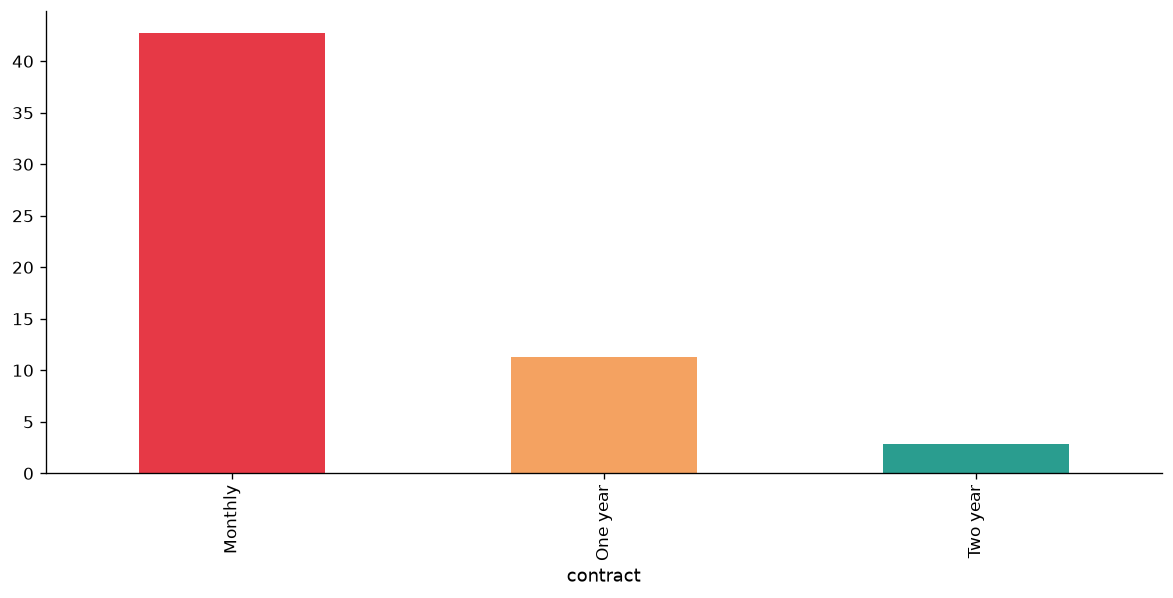

In [192]:
churn_by_contract.plot(kind='bar', color= bar_colors)

In [193]:
#6. Group Revenue by Segment
revenue_by_segment = (
    customer.groupby('revenue_segment')['monthlycharges'].mean()
    .sort_values(ascending=False)
)
print(revenue_by_segment)

revenue_segment
VIP       124485.625474
High       96576.405530
Medium     61746.218728
Low        26307.646717
Name: monthlycharges, dtype: float64


<Axes: xlabel='revenue_segment'>

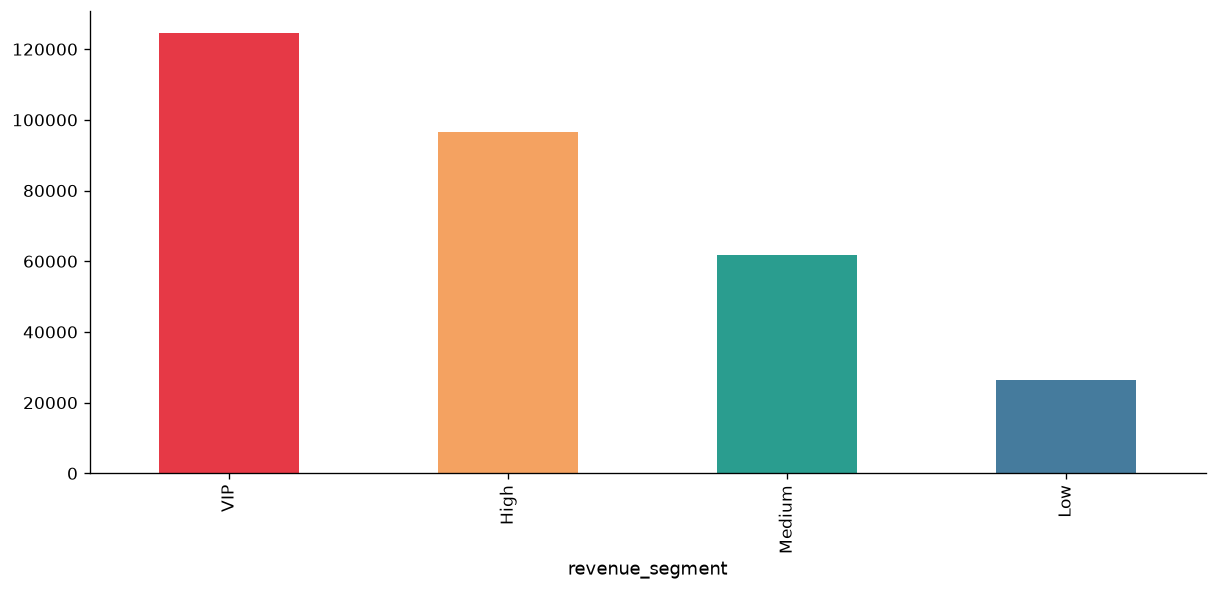

In [194]:
revenue_by_segment.plot(kind='bar', color= bar_colors_extended)

In [195]:
#7. Digital Dependency Score Analysis
digital_dependency_avg = (
    customer['digital_dependency_score'].mean()
)
print(f'The average customer digital dependency score is {digital_dependency_avg.round(0)} out of {customer['digital_dependency_score'].max()}.')

The average customer digital dependency score is 2.0 out of 6.


In [196]:
#8. Customer Tenure Analysis
avg_tenure = (
    customer['tenure'].mean()
)
print(f'The average tenure used by customer before churn is {avg_tenure.round(0)} months.')

The average tenure used by customer before churn is 32.0 months.


In [197]:
#9. Categorize Churn by Tenure Group
churn_by_tenure = (
    customer.groupby('tenure_group')['churn'].mean()
    .sort_values(ascending= False) 
    * 100
)
print(churn_by_tenure)

tenure_group
New            47.438243
Growing        28.710938
Established    20.388959
Loyal           9.513176
Name: churn, dtype: float64


<Axes: xlabel='tenure_group'>

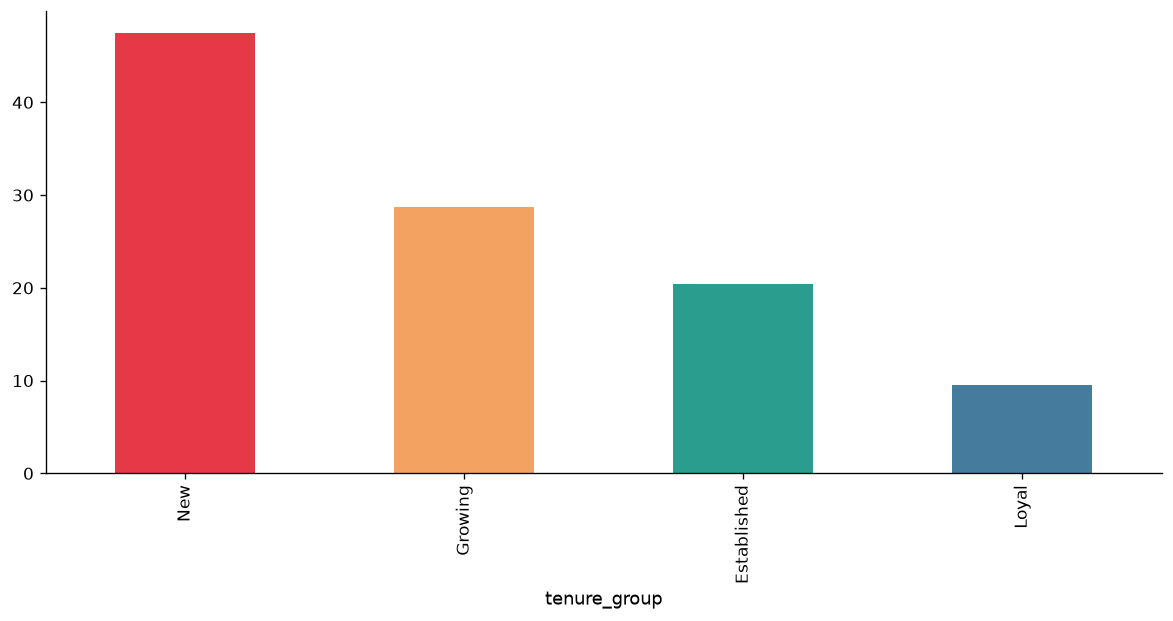

In [198]:
churn_by_tenure.plot(kind='bar', color= bar_colors_extended)

In [199]:
#10. Payment Method Analysis
payment_churn = (
    customer.groupby('paymentmethod')['churn'].mean()
    .sort_values(ascending=False)
    * 100 
)
print(payment_churn)

paymentmethod
Manual                       34.674378
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: churn, dtype: float64


<Axes: xlabel='paymentmethod'>

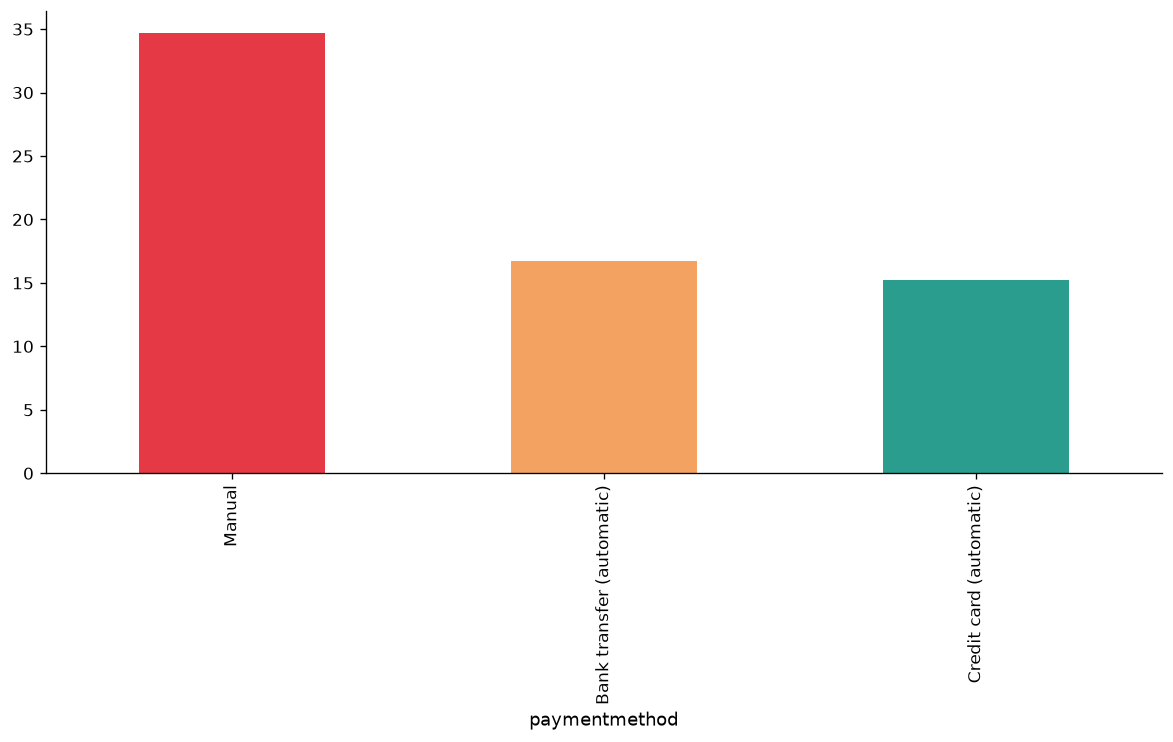

In [200]:
payment_churn.plot(kind='bar', color= bar_colors)

#### 2. Transaction KPI Engineering

In [201]:
#1. Total Transaction Volume
total_transaction_volume = (
    transactions['amount'].count()
)
print(f'The total transaction made is {total_transaction_volume} transactions.')

The total transaction made is 1000000 transactions.


In [202]:
#2. Total Transaction Value
total_transaction_value = (
    transactions['amount'].sum()
)
print(f'The net transaction value performed is ₦{total_transaction_value.round(2):,.2f}.')

The net transaction value performed is ₦156,951,422,091.41.


In [203]:
#3. Average Transaction Value
avg_transaction_value = (
    transactions['amount'].mean()
)
print(f'The average transaction performed is ₦{avg_transaction_value.round(2):,.2f}.')
    

The average transaction performed is ₦156,951.42.


In [204]:
#4. High Transaction Share
high_value_rate = (
    transactions['high_value_txn'].mean() * 100
)
print(f'{high_value_rate}% of the total transaction are high value transactions.')

5.0% of the total transaction are high value transactions.


In [205]:
#5. Transactions by Channel
transactions_by_channel = (
    transactions['channel'].value_counts(normalize=True)
    * 100
)
print(transactions_by_channel)

channel
Mobile    44.9522
Web       20.0488
POS       18.0035
IB         9.9653
ECOM       5.0227
ATM        2.0075
Name: proportion, dtype: float64


<Axes: xlabel='channel'>

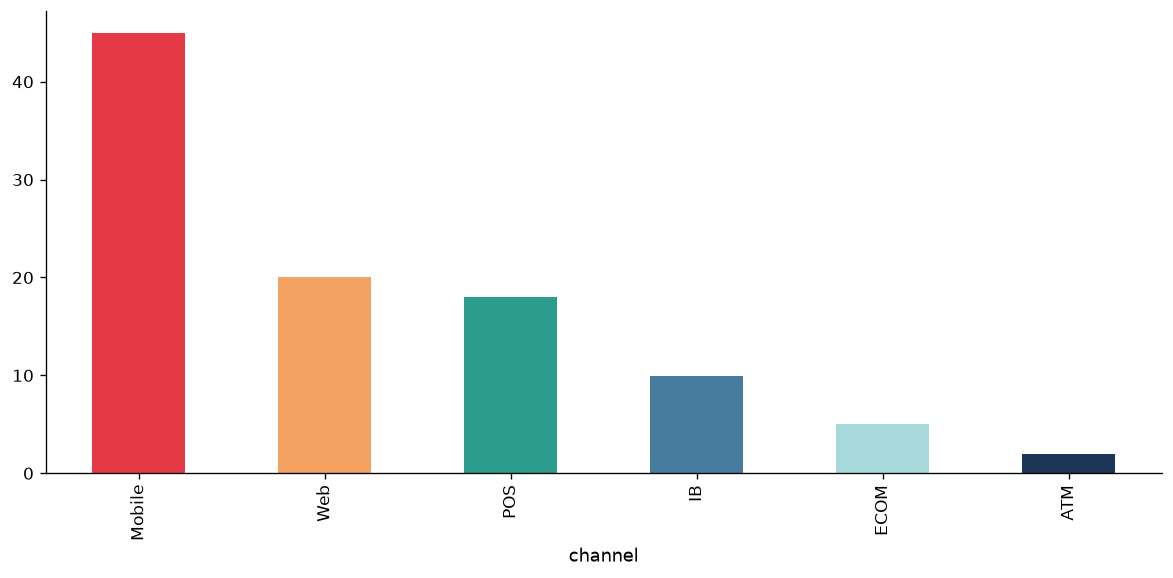

In [206]:
transactions_by_channel.plot(kind='bar', color =bar_colors_extended)

In [207]:
#6. Regional Transaction Analysis
regional_txn_vol = (
    transactions.groupby('region')['amount'].sum()
    .sort_values(ascending=False)
)
print(regional_txn_vol)

region
Lagos            8.030087e+10
Abuja            5.752671e+10
Kano             8.104487e+09
Port Harcourt    6.238352e+09
Ibadan           4.781010e+09
Name: amount, dtype: float64


<Axes: xlabel='region'>

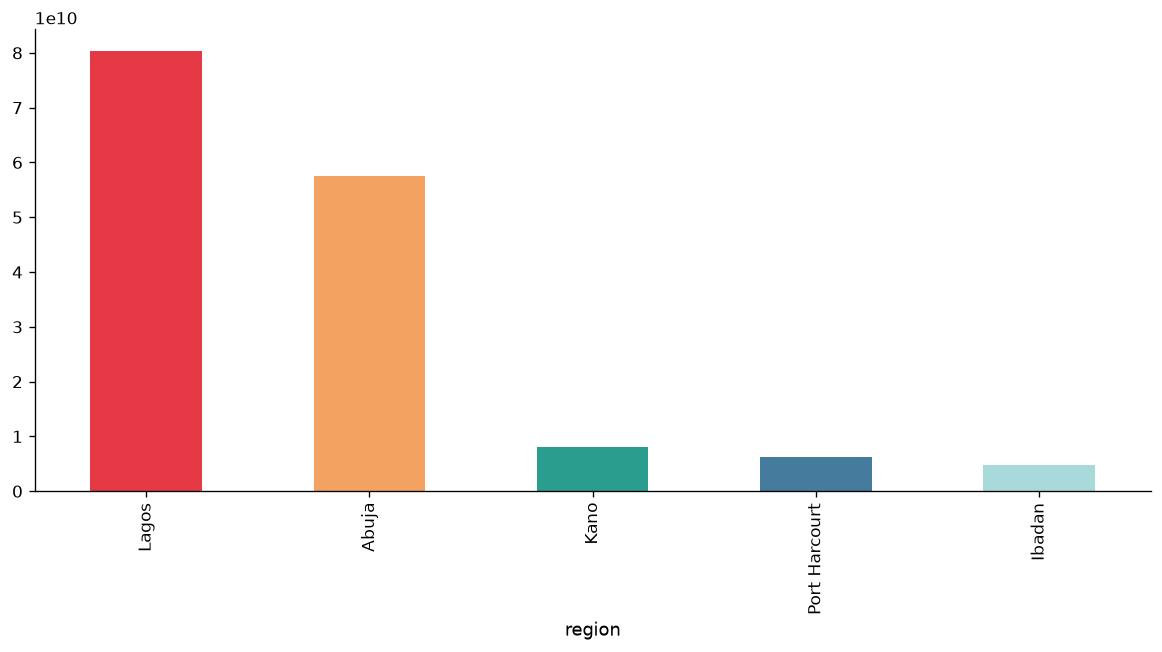

In [208]:
regional_txn_vol.plot(kind='bar', color= bar_colors_extended)

In [209]:
#7. Peak Hour Transaction Rate
peak_hour_rate = (
    transactions['is_peak_hr'].mean()
    * 100
)
print(f'The rate at which peak hour transaction (8am-8pm) is performed is {peak_hour_rate}%.')

The rate at which peak hour transaction (8am-8pm) is performed is 82.8147%.


In [210]:
#8. Night Transaction Rate
night_txn_rate = (
    transactions['night_transaction'].mean()
    * 100
)
print(f'The rate at which night transaction from 10pm-5am is performed is {night_txn_rate.round(2)}%.')

The rate at which night transaction from 10pm-5am is performed is 12.48%.


In [211]:
#9. Average Customer Transaction Count
avg_customer_txn = (
    transactions.groupby('customer_id')['transaction_id']
    .count().mean()
)
print(f'The average transaction performed by customers is {avg_customer_txn.round(0)} transactions.')

The average transaction performed by customers is 142.0 transactions.


In [212]:
#10. Transaction Size Distribution
transaction_size_dist = (
    transactions['transaction_size'].value_counts(normalize=True)
    * 100
)
print(transaction_size_dist)

transaction_size
Small         25.0
Medium        25.0
Large         25.0
Enterprise    25.0
Name: proportion, dtype: float64


<Axes: >

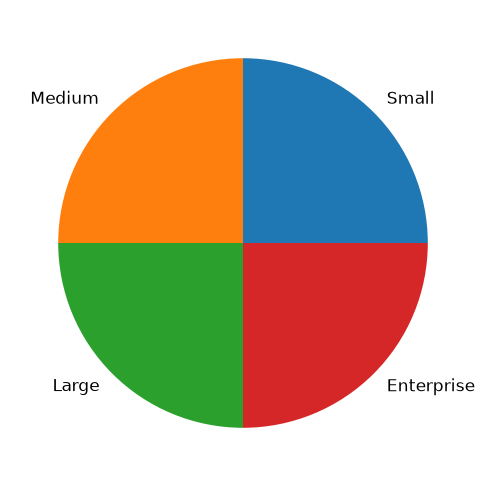

In [213]:
transaction_size_dist.plot(kind='pie', color= bar_colors_extended)

In [214]:
#11. Weekend Transaction Rate
weekend_rate = (
    transactions['is_weekend'].mean()
    * 100
)
print(f'The rate of transactions performed during weekends is {weekend_rate.round(2)}%.')

The rate of transactions performed during weekends is 28.68%.


In [215]:
#12. Top Spending Customers
top_customers = (
    transactions.groupby('customer_id')['amount'].sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_customers)

customer_id
Cust_06915    47063488.71
Cust_03905    45804690.60
Cust_02026    43646980.92
Cust_00508    40889317.88
Cust_05718    40356392.66
Cust_03515    40258259.53
Cust_00987    39578551.40
Cust_02880    39429731.85
Cust_00725    39399141.09
Cust_01307    39266577.83
Name: amount, dtype: float64


<Axes: xlabel='customer_id'>

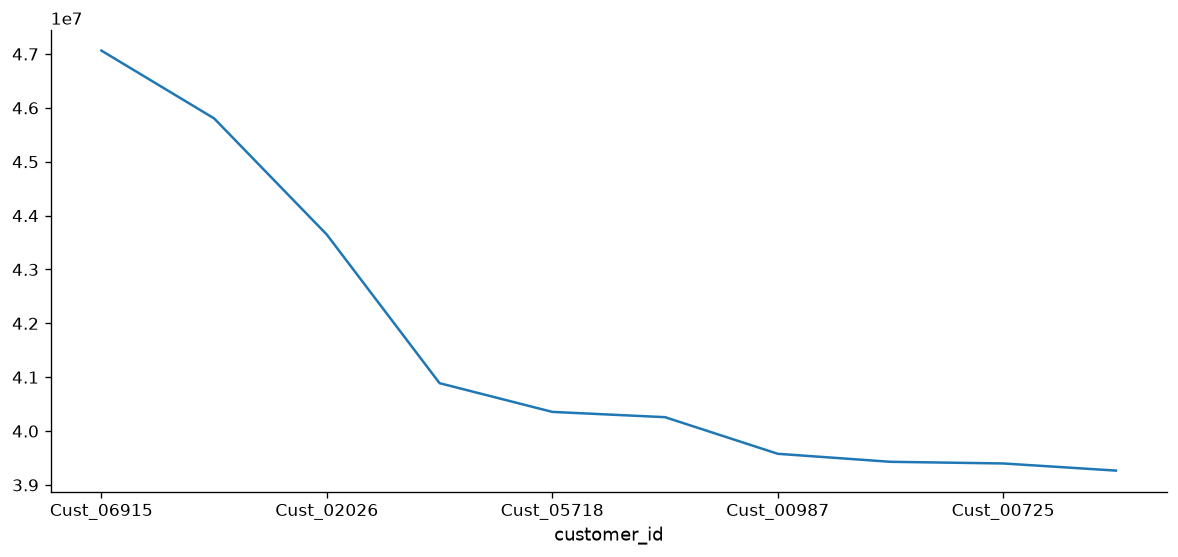

In [216]:
top_customers.plot()

In [217]:
#13. Transaction Trend over Time
daily_txn_trend = (
    transactions.groupby(transactions['transaction_time'].dt.date)['amount'].sum()
)
print(daily_txn_trend)

transaction_time
2023-01-01    3.431783e+08
2023-01-02    3.367257e+08
2023-01-03    3.497726e+08
2023-01-04    3.181107e+08
2023-01-05    3.429829e+08
                  ...     
2023-12-27    6.154450e+08
2023-12-28    5.927063e+08
2023-12-29    5.999018e+08
2023-12-30    5.976649e+08
2023-12-31    5.838481e+08
Name: amount, Length: 365, dtype: float64


<Axes: xlabel='transaction_time'>

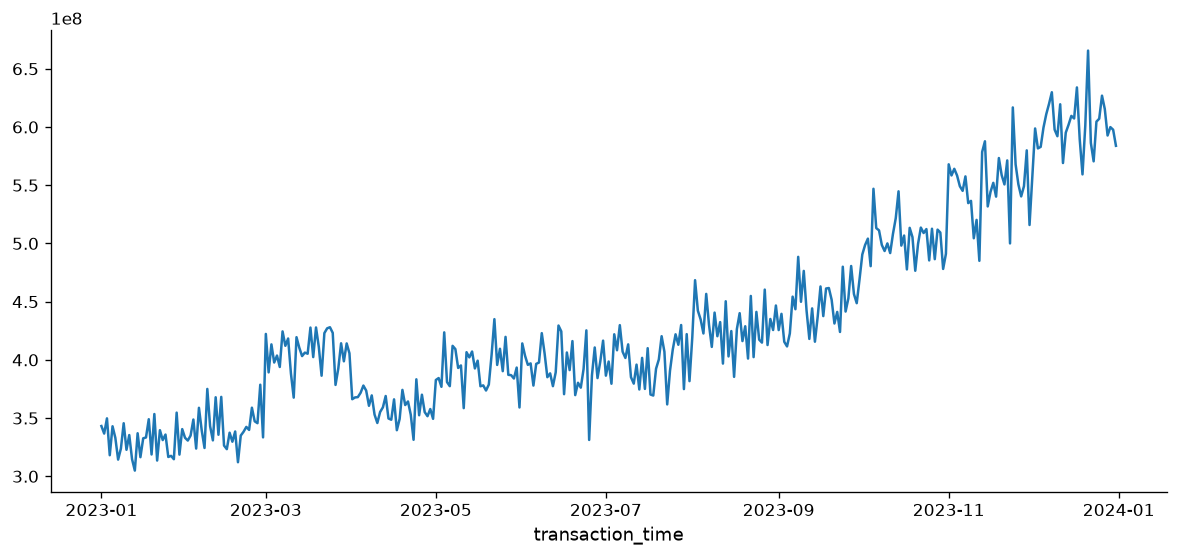

In [218]:
daily_txn_trend.plot()

#### 3. Fraud KPI Engineering

In [219]:
#1. Fraud Rate
fraud_rate = (
    fraud_log['is_fraud'].astype(float).mean()
    * 100
)
print(f'The fraud rate is {fraud_rate}%.')

The fraud rate is 0.3%.


In [220]:
#2. Total Fraud Amount
total_fraud_amount = (fraud_log[
    fraud_log['is_fraud'] == 1]
    ['amount'].sum())
print(f'The total amount of fraud transactions executed is ₦{total_fraud_amount:,.2f}.')        

The total amount of fraud transactions executed is ₦1,154,876,055.34.


In [221]:
#3. Legitimate Transaction Value (Net Clean Revenue) 
non_fraud_amount = (fraud_log[
    fraud_log['is_fraud'] == 0]
    ['amount'].sum())
print(f'The overall legitimate transaction value is ₦{non_fraud_amount:,.2f}.') 

The overall legitimate transaction value is ₦155,796,546,036.07.


In [222]:
#4. Average Fraud Risk Score
avg_fraud_risk = (
    fraud_log['composite_risk'].mean()
)
print(f'The average fraud risk score is {avg_fraud_risk.round(2)}.')

The average fraud risk score is 0.15.


In [223]:
#5. Fraud by Region
fraud_log['is_fraud'] = fraud_log['is_fraud'].astype(float)
fraud_by_region = (
    fraud_log.groupby('region')['is_fraud']
    .mean()
    * 100).sort_values(ascending=False)

print(fraud_by_region)

region
Kano             0.354707
Port Harcourt    0.313960
Lagos            0.300905
Ibadan           0.300270
Abuja            0.289626
Name: is_fraud, dtype: float64


<Axes: xlabel='region'>

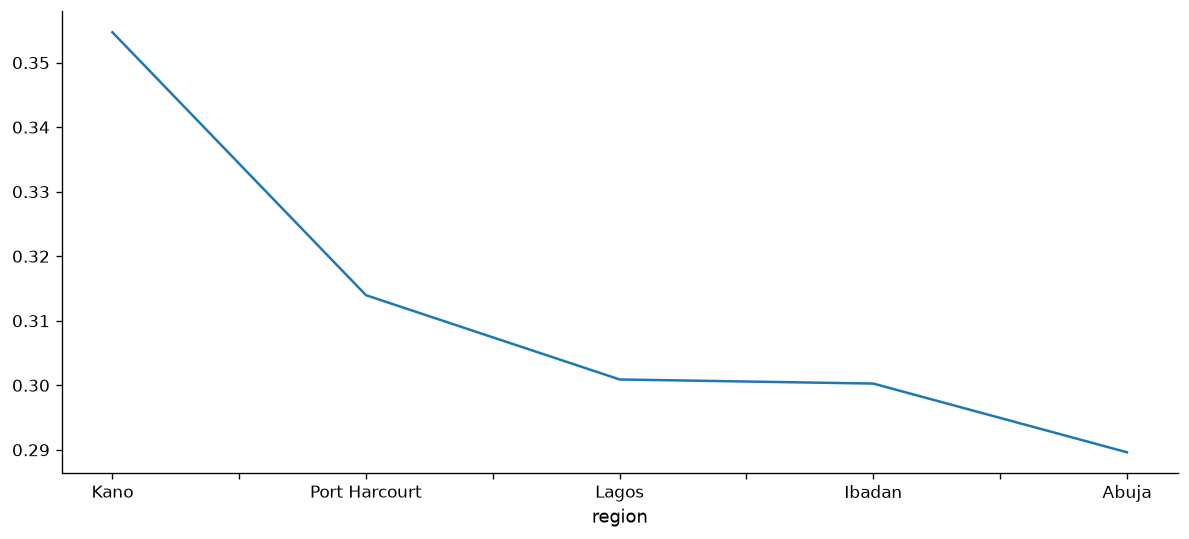

In [224]:
fraud_by_region.plot()

In [225]:
#6. Geographic Fraud Risk Profile
region_risk_matrix = (
    fraud_log.groupby('region')
    .agg(
        fraud_incidence_rate = ('is_fraud', lambda x: x.mean() * 100),
        total_fraud_loss = ('amount', lambda x: x[fraud_log.loc[x.index, 'is_fraud'] == 1].sum()),
        total_transactions = ('amount', 'count')
    ).sort_values(by='fraud_incidence_rate', ascending=False)
)
## Format the results cleanly
region_risk_matrix['fraud_incidence_rate'] = region_risk_matrix['fraud_incidence_rate'].map('{:.2f}%'.format)
region_risk_matrix['total_fraud_loss'] = region_risk_matrix['total_fraud_loss'].map('₦{:,.2f}'.format)

print(region_risk_matrix)

              fraud_incidence_rate total_fraud_loss  total_transactions
region                                                                 
Kano                         0.35%   ₦90,801,041.22               51028
Port Harcourt                0.31%   ₦62,115,477.06               39177
Lagos                        0.30%  ₦558,168,180.56              513118
Ibadan                       0.30%   ₦32,844,462.18               29307
Abuja                        0.29%  ₦410,946,894.32              367370


/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_41033/1359616493.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_41033/1359616493.py:11: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(


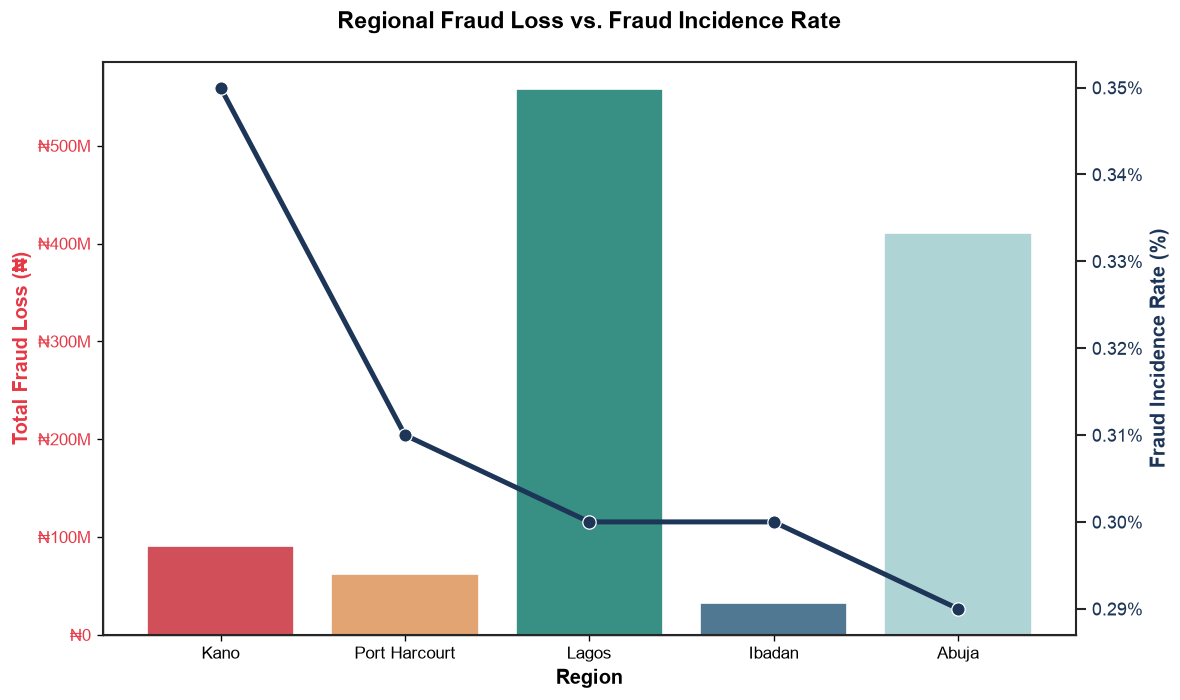

In [226]:
# 1. Convert strings back into numbers
chart_data = region_risk_matrix.copy()
chart_data['fraud_incidence_rate'] = chart_data['fraud_incidence_rate'].str.replace('%', '').astype(float)
chart_data['total_fraud_loss'] = chart_data['total_fraud_loss'].str.replace('₦', '').str.replace(',', '').astype(float)

# 2. Initialize the plot layout
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.set_theme(style="white")

# 3.Total Fraud Loss (Naira) as Bar Chart (Primary Axis)
sns.barplot(
    x=chart_data.index, 
    y='total_fraud_loss', 
    data=chart_data, 
    ax=ax1, 
    palette=bar_colors_extended
)

ax1.set_title('Regional Fraud Loss vs. Fraud Incidence Rate', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Fraud Loss (₦)', fontsize=12, color='#E63946', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#E63946')

# Format the Naira axis numbers
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x*1e-6:.0f}M' if x >= 1e6 else f'₦{x:,.0f}'))

# 4.Fraud Incidence Rate (%) (Secondary Axis)
ax2 = ax1.twinx()
sns.lineplot(
    x=chart_data.index, 
    y='fraud_incidence_rate', 
    data=chart_data, 
    ax=ax2, 
    color='#1D3557', 
    linewidth=3, 
    marker='o', 
    markersize=8
)

ax2.set_ylabel('Fraud Incidence Rate (%)', fontsize=12, color='#1D3557', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#1D3557')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}%'))

# Adjust layouts and render
plt.tight_layout()
plt.show()


In [227]:
#7. Fraud Severity Distribution
fraud_severity_dist = (
    fraud_log['fraud_severity']
    .value_counts(normalize=True)
    * 100).round(2)

print(fraud_severity_dist)

fraud_severity
Low         36.89
Moderate    31.55
High        26.56
Critical     5.01
Name: proportion, dtype: float64


<Axes: xlabel='fraud_severity'>

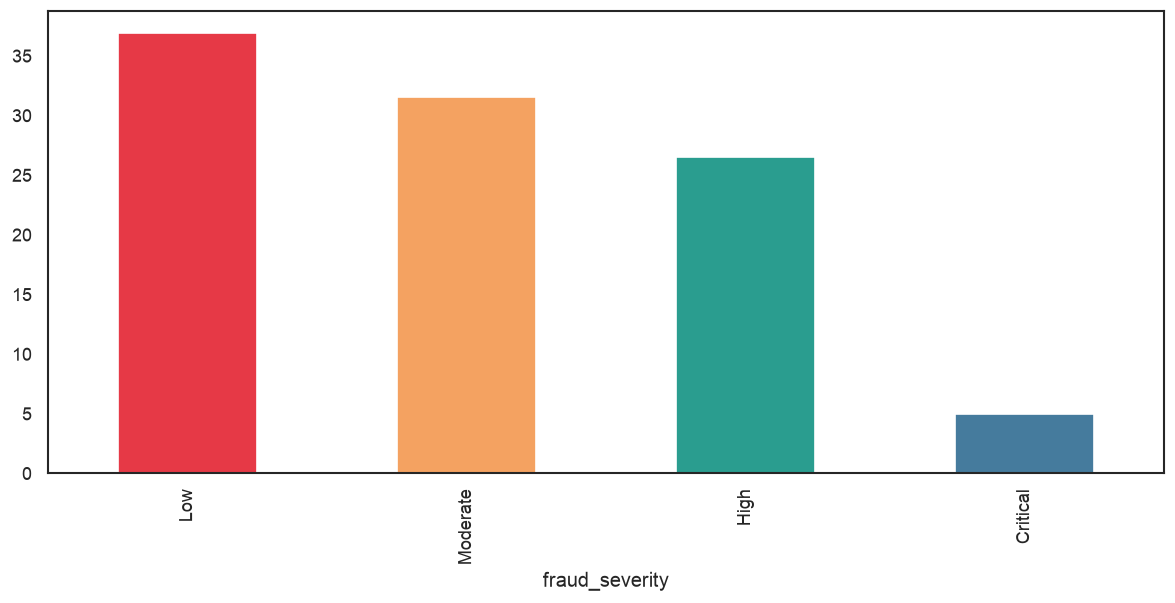

In [228]:
fraud_severity_dist.plot(kind='bar', color=bar_colors_extended)

In [229]:
#8. Night Fraud Share
fraudulent_txns = fraud_log[fraud_log['is_fraud'] == 1]
night_fraud_rate = fraudulent_txns['night_fraud_flag'].mean() * 100

print(f'The share of total fraud occurring at night is {night_fraud_rate:.2f}%.')

The share of total fraud occurring at night is 12.83%.


In [230]:
#9. High Velocity Flag Share
high_velocity_flag_share = (
    fraud_log['high_velocity_flag'].mean()
    * 100)
print(f' The percentage share of high velocity alert is {high_velocity_flag_share:.2f}%.')

 The percentage share of high velocity alert is 5.00%.


In [231]:
#-- Fraud Conversion Rate
velocity_fraud_conversion= (
    fraud_log.groupby('high_velocity_flag')['is_fraud']
    .mean()
    * 100
)
print(velocity_fraud_conversion.map('{:.2f}%'.format))

high_velocity_flag
0    0.30%
1    0.25%
Name: is_fraud, dtype: str


In [232]:
#-- Geographical Share of High Velocity Alerts
velocity_active_log = (
    fraud_log[fraud_log['high_velocity_flag'] == 1]
)
velocity_geo_share = (
    velocity_active_log['region'].value_counts(normalize=True)
    .sort_values(ascending=False) * 100
)
print(velocity_geo_share.map('{:.2f}%'.format))

region
Lagos            51.55%
Abuja            36.45%
Kano              5.13%
Port Harcourt     3.92%
Ibadan            2.95%
Name: proportion, dtype: str


<Axes: >

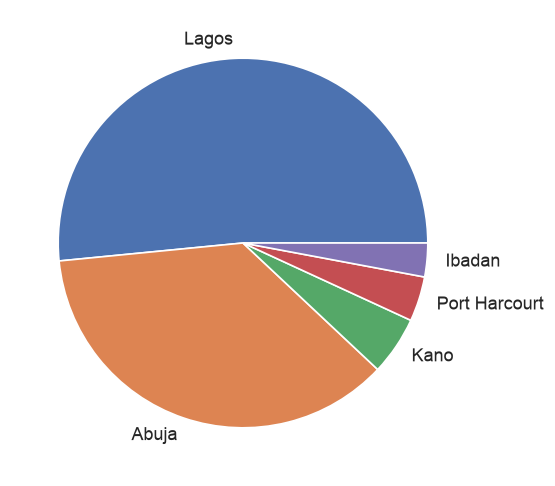

In [233]:
velocity_geo_share.plot(kind='pie', color=bar_colors_extended)

In [234]:
## Insight 
##The data proves that Lagos and Abuja are under heavy network load and attack, but the current velocity rules are completely blind 
##to the actual fraudulent behavior.
##What to do?
#fix the velocity rules, making it stricter for regions like Lagos and Abuja

In [235]:
#10. High Merchant Exposure Share
high_merch_exposure_share = (
    fraud_log['high_merchant_risk'].mean()
    * 100)
print(f'The platform exposure to high-risk merchant is {high_merch_exposure_share.round(2)}%.') 

The platform exposure to high-risk merchant is 14.34%.


In [236]:
##-- Merchant Fraud Conversion Rate
merchant_fraud_conversion = (
    fraud_log.groupby('high_merchant_risk')['is_fraud']
    .mean()
    * 100
)
print(merchant_fraud_conversion.map('{:.2f}%'.format))

high_merchant_risk
0    0.30%
1    0.30%
Name: is_fraud, dtype: str


In [237]:
## NB- The high risk merchant flag has no predictive power.

In [238]:
##-- Total Monetary Loss by Merchant Risk Tiers
merchant_financial_impact = (
    fraud_log[fraud_log['is_fraud'] == 1]
    .groupby('high_merchant_risk')['amount']
    .sum()
)
print(merchant_financial_impact.map('₦{:,.2f}'.format))

high_merchant_risk
0    ₦965,809,641.68
1    ₦189,066,413.66
Name: amount, dtype: str


In [239]:
#11. Critical Fraud Pressure Rate
critical_pressure_rate = (
    (fraud_log['fraud_pressure_category'] == 'Critical Pressure')
    .mean()
) * 100
print(f'The critical pressure rate is {critical_pressure_rate}%.')

The critical pressure rate is 25.0%.


In [240]:
#12. Top High Risk Customers
top_risky_customers = (
    fraud_log.groupby('customer_id')['fraud_pressure_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_risky_customers)

customer_id
Cust_03548    4.034382
Cust_00169    3.986469
Cust_03282    3.953616
Cust_01859    3.870041
Cust_01987    3.860565
Cust_05508    3.855846
Cust_02856    3.809176
Cust_00886    3.782571
Cust_05471    3.766876
Cust_02939    3.749054
Name: fraud_pressure_score, dtype: float64


<Axes: ylabel='customer_id'>

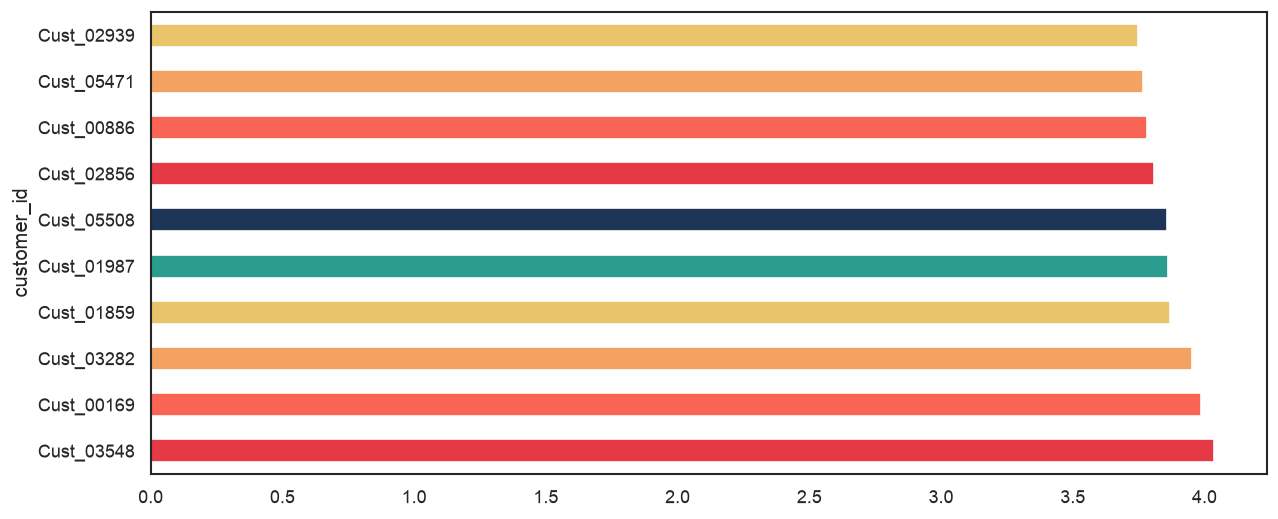

In [241]:
bar_colors = ['#E63946', '#FA6454', '#F4A261', '#E9C46A', '#2A9D8F', '#1D3557']
top_risky_customers.plot(kind='barh', color= bar_colors)

In [242]:
#13. Fraud Trend Over Time
fraud_trend = (
    fraud_log.groupby(
        fraud_log['timestamp'].dt.date)
    ['is_fraud'].sum()
)
print(fraud_trend)

timestamp
2023-01-01     9.0
2023-01-02     6.0
2023-01-03    13.0
2023-01-04    12.0
2023-01-05     9.0
              ... 
2023-12-27     1.0
2023-12-28     2.0
2023-12-29    12.0
2023-12-30     3.0
2023-12-31     6.0
Name: is_fraud, Length: 365, dtype: float64


<Axes: xlabel='timestamp'>

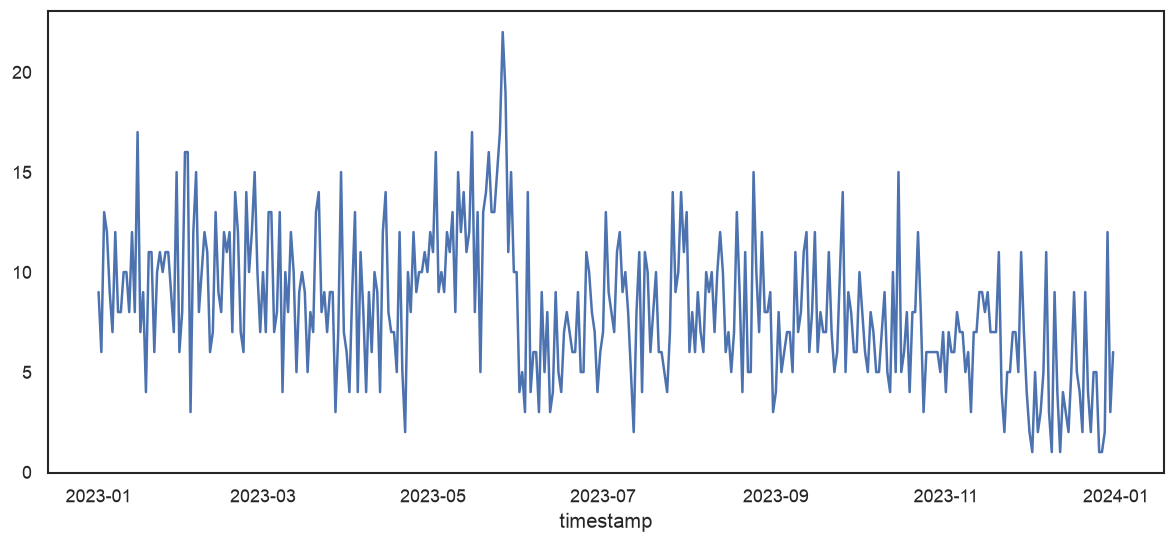

In [243]:
fraud_trend.plot()

In [244]:
#14. Fraud by Payment Channel
fraud_by_channel = (
    (fraud_log.groupby('channel')['is_fraud']
    .mean()
    * 100)
    .sort_values(ascending=False)
)
print(fraud_by_channel)   

channel
Web       0.342664
Mobile    0.332798
POS       0.306052
IB        0.168585
ECOM      0.151313
ATM       0.109589
Name: is_fraud, dtype: float64


<Axes: xlabel='channel'>

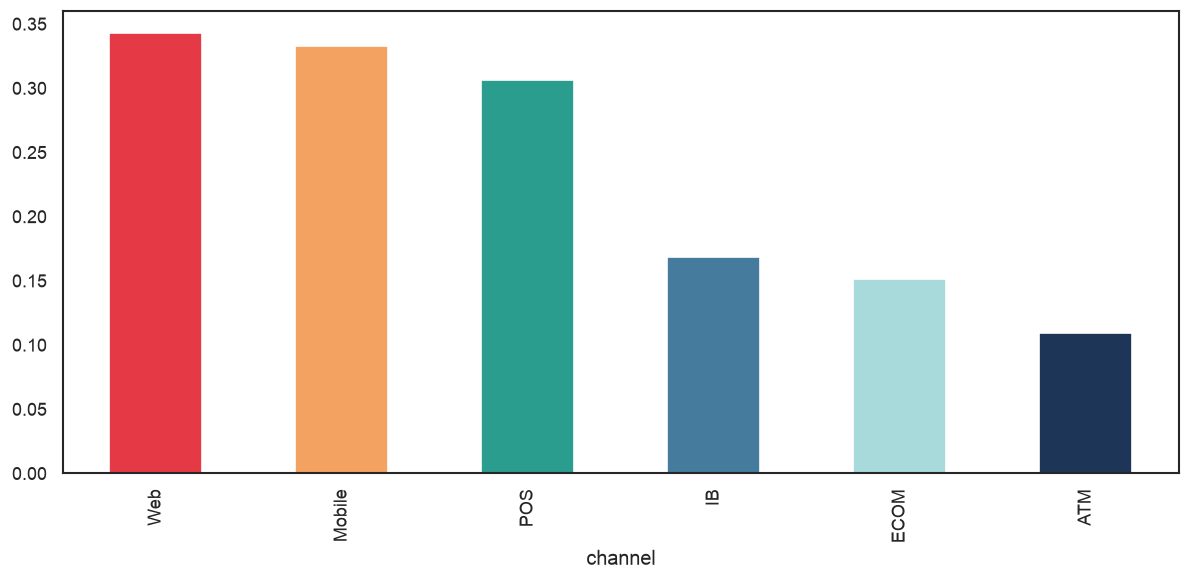

In [245]:
fraud_by_channel.plot(kind='bar', color= bar_colors_extended)

In [246]:
#15. Average Fraud Pressure
avg_fraud_pressure = fraud_log[
    'fraud_pressure_score'
].mean()

print(f'The average fraud pressure rate is {avg_fraud_pressure.round(2)}.')

The average fraud pressure rate is 2.45.


In [247]:
#16. Fraud Concentration by Merchant Category
fraud_by_merchant = (
    (fraud_log.groupby('merchant_category')['is_fraud']
    .mean()
    * 100)
    .sort_values(ascending=False)
)
print(fraud_by_merchant)

merchant_category
ATM_Withdrawal    0.338155
Electronics       0.331966
Retail            0.328021
Bill_Payment      0.318626
Airtime           0.310585
Transfer          0.310359
Restaurant        0.305264
Fuel              0.293820
Medical           0.291700
Entertainment     0.285367
Education         0.280966
Grocery           0.278349
Transport         0.266998
Fashion           0.259631
Name: is_fraud, dtype: float64


#### 3. Customer Support KPI Engineering

In [248]:
#1. Average Resolution Time
avg_resolution_time = (
    customer_support['resolution_time_hours'].mean()
)
print(f'The average resolution time is {avg_resolution_time.round(2)}hrs.')

The average resolution time is 94.34hrs.


In [249]:
#2. SlA Breach Rate
sla_breach_rate = (
    customer_support['sla_breached'] =='Yes').mean()* 100
print(f'The SLA breach rate is about {sla_breach_rate.round(2)}%.')

The SLA breach rate is about 50.24%.


In [250]:
#3. Customer Satisfaction Score
avg_customer_satisfaction = (
    customer_support['customer_satisfaction_score'].mean()
)
print(f'The average customer satisfaction score is {avg_customer_satisfaction.round(2)}.')

The average customer satisfaction score is 3.18.


In [251]:
#4. Escalation Rate
escalation_rate = (
    customer_support['escalated']== 'Yes').mean() * 100
print(f'The overall escalation rate is {escalation_rate.round(2)}%.')

The overall escalation rate is 50.04%.


In [252]:
#5. High Escalation Risk Rate
high_esc_risk_rate =(
    customer_support['high_escalation_risk']
    .mean()
) * 100

print(f'High escalation risk rate is {high_esc_risk_rate.round(2)}%.') 

High escalation risk rate is 11.43%.


In [253]:
#6. Resolution Time By Priority
resolution_by_priority = (
    customer_support.groupby('priority')['resolution_time_hours']
    .mean()
    .sort_values(ascending=False)
)
print(resolution_by_priority.round(2))

priority
Low       145.79
Medium     60.28
High       17.72
Urgent      3.62
Name: resolution_time_hours, dtype: float64


<Axes: xlabel='priority'>

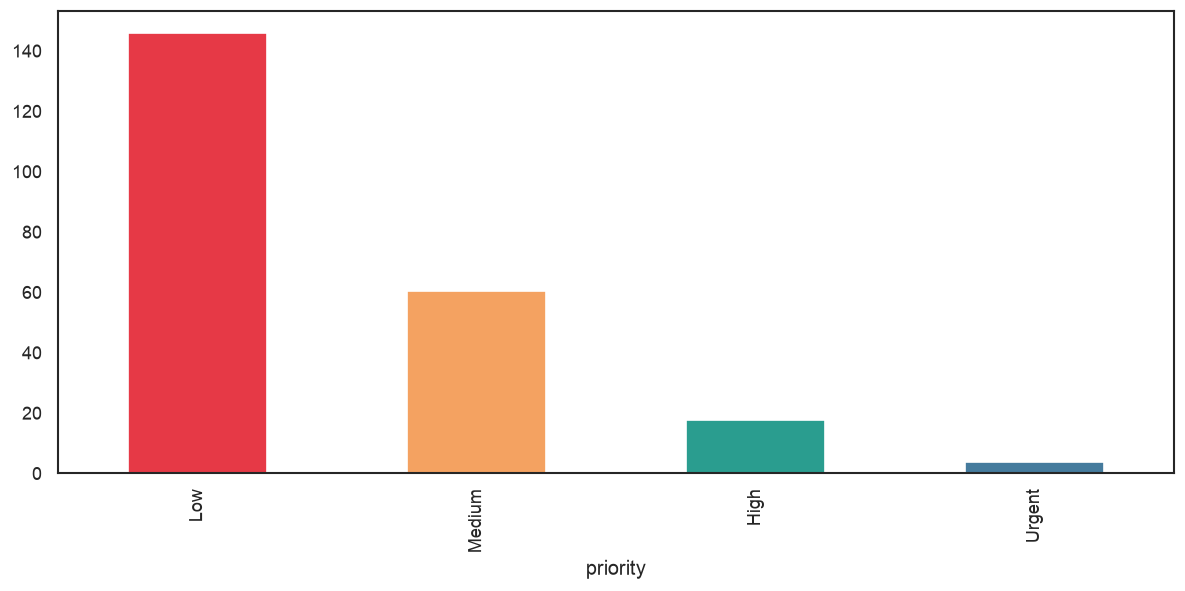

In [254]:
resolution_by_priority.plot(kind='bar', color= bar_colors_extended)

In [255]:
#7. Ticket Volume by Channel
ticket_channel_distribution = (
    customer_support['channel']
    .value_counts(normalize=True)
) * 100

print(ticket_channel_distribution.round(2))

channel
Email           20.17
Phone           20.07
Chat            20.01
Web Form        19.88
Social Media    19.87
Name: proportion, dtype: float64


<Axes: >

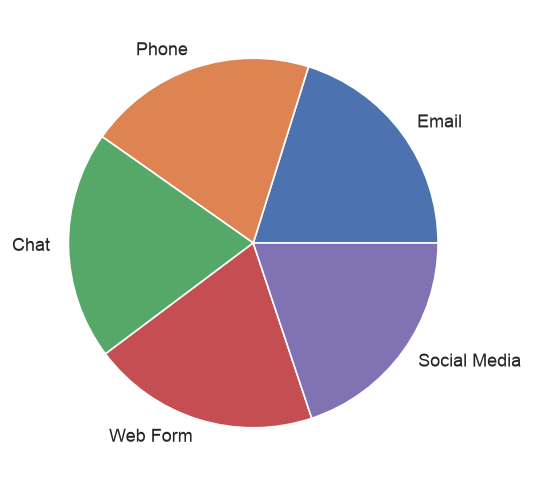

In [256]:
ticket_channel_distribution.plot(kind='pie', color= bar_colors_extended)

In [257]:
#8. Response Time Analysis
avg_time_response = (
    customer_support['first_response_time_hours'].mean()
)
print(f'The average response time is {avg_time_response.round(2)}hrs.')

The average response time is 33.84hrs.


In [258]:
#9. Customer Segment Support Pressure
segment_support_pressure = (
    customer_support.groupby('customer_segment')['previous_tickets']
    .mean()
    .sort_values(ascending=False)
)
print(segment_support_pressure.round(2))

customer_segment
Individual        10.03
Small Business    10.00
Corporate          9.91
Name: previous_tickets, dtype: float64


<Axes: xlabel='customer_segment'>

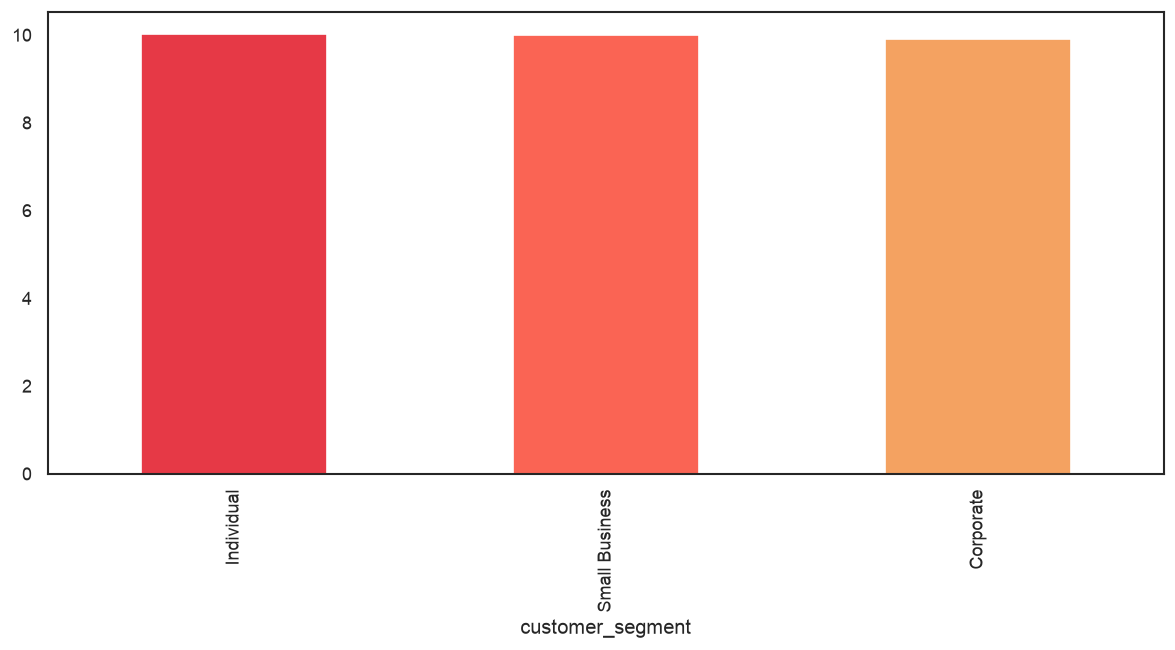

In [259]:
segment_support_pressure.plot(kind='bar', color= bar_colors)

In [260]:
#10. Operational Complexity Analysis Matrix
complexity_analysis_matrix = customer_support.groupby('issue_complexity_score').agg(
    total_tickets=('resolution_time_hours', 'count'),
    median_resolution_hours=('resolution_time_hours', 'median'),
    sla_breach_rate=('sla_breached', lambda x: (x == 'Yes').mean() * 100),
    average_csat=('customer_satisfaction_score', 'mean')
).sort_index()

print(complexity_analysis_matrix.round(2))


                        total_tickets  median_resolution_hours  \
issue_complexity_score                                           
1                               19981                     73.5   
2                               19860                     74.1   
3                               19532                     75.8   
4                               19960                     70.6   
5                               19774                     74.9   
6                               19842                     72.7   
7                               20195                     73.2   
8                               19975                     73.2   
9                               20283                     77.6   
10                              20598                     74.3   

                        sla_breach_rate  average_csat  
issue_complexity_score                                 
1                                 49.63          3.14  
2                                 50.20

In [261]:
#11. Support Performance by Region
support_performance_region = (
    customer_support.groupby('region')['customer_satisfaction_score']
    .mean()
    .sort_values(ascending=False)
)
print(support_performance_region)

region
Abuja            3.187415
Port Harcourt    3.181749
Kano             3.180848
Ibadan           3.178370
Lagos            3.167025
Name: customer_satisfaction_score, dtype: float64


<Axes: xlabel='region'>

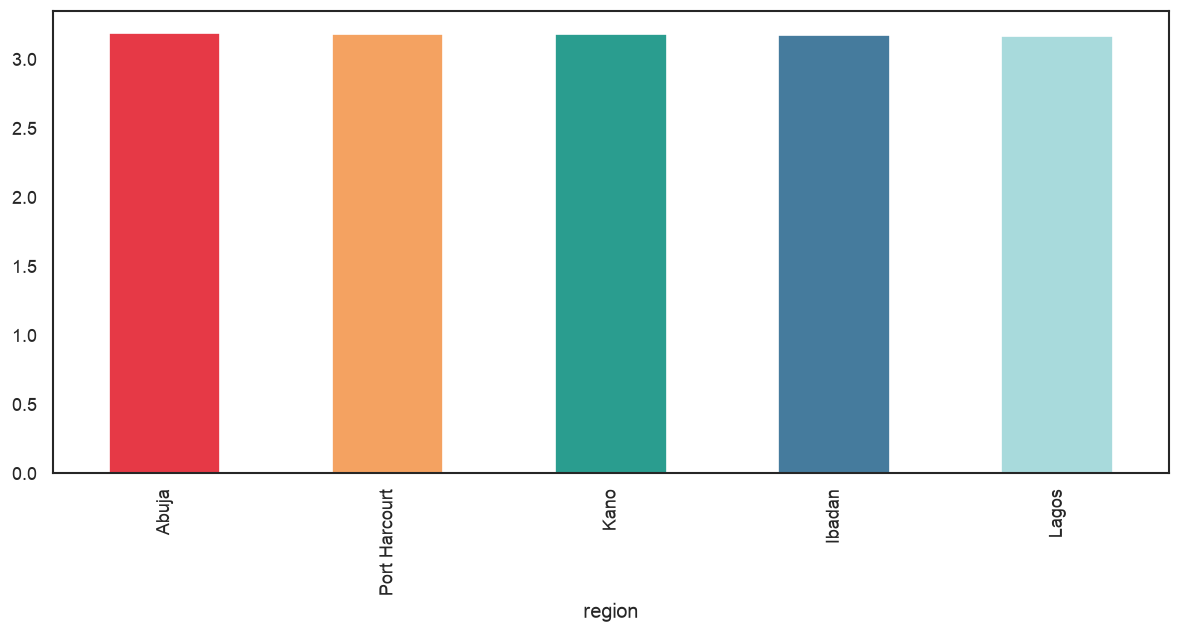

In [262]:
support_performance_region.plot(kind='bar', color= bar_colors_extended)

In [263]:
#12. Measure Operational Urgency Loan (by determining high priority ticket rate)
high_priority_rate = (
    customer_support['priority'].isin(
        ['High', 'Urgent']
    ).mean()
        * 100
)
print(f'The percentage of high priority tickets is {high_priority_rate.round(1)}%.')

The percentage of high priority tickets is 15.3%.


In [264]:
#13. Category Resolution Analysis to Identify Difficult Issues
category_resolution = (
    customer_support.groupby('category')
    ['resolution_time_hours'].mean()
    .sort_values(ascending=False)
)
print(category_resolution)

category
Performance Issue            96.868506
Payment Problem              96.142704
Data Sync Issue              94.986222
Account Suspension           94.358947
Security Concern             94.193730
Subscription Cancellation    94.083575
Login Issue                  93.835691
Feature Request              93.829474
Refund Request               93.559379
Bug Report                   92.195581
Name: resolution_time_hours, dtype: float64


<Axes: xlabel='category'>

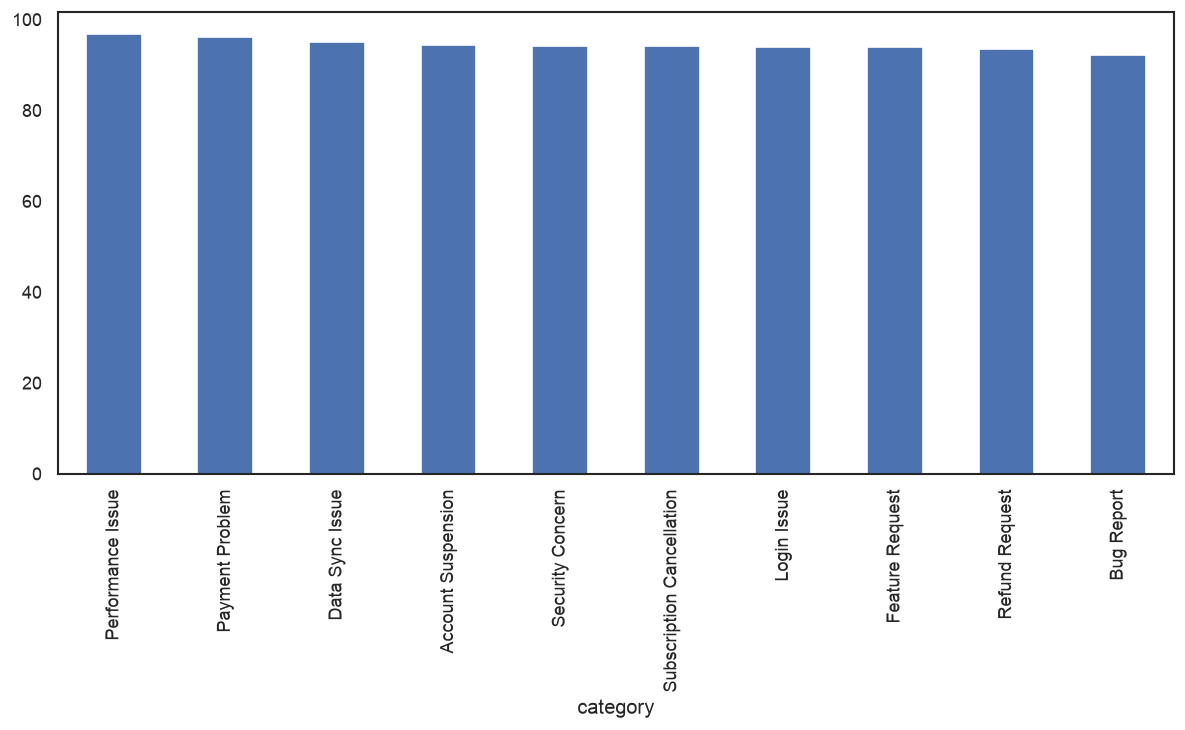

In [265]:
category_resolution.plot(kind='bar')

In [266]:
#14. Daily Ticket Trend
daily_ticket_trend = (
    customer_support.groupby(
        customer_support['ticket_created_date'].dt.date
            )['ticket_id']
    .count()
    .sort_values(ascending=False)
)
print(daily_ticket_trend )

ticket_created_date
2022-07-02    310
2024-05-12    306
2023-12-02    297
2022-06-15    293
2024-04-05    282
             ... 
2023-06-27    108
2023-10-08    107
2024-09-04    105
2024-01-30     96
2023-02-03     85
Name: ticket_id, Length: 1096, dtype: int64


<Axes: xlabel='ticket_created_date'>

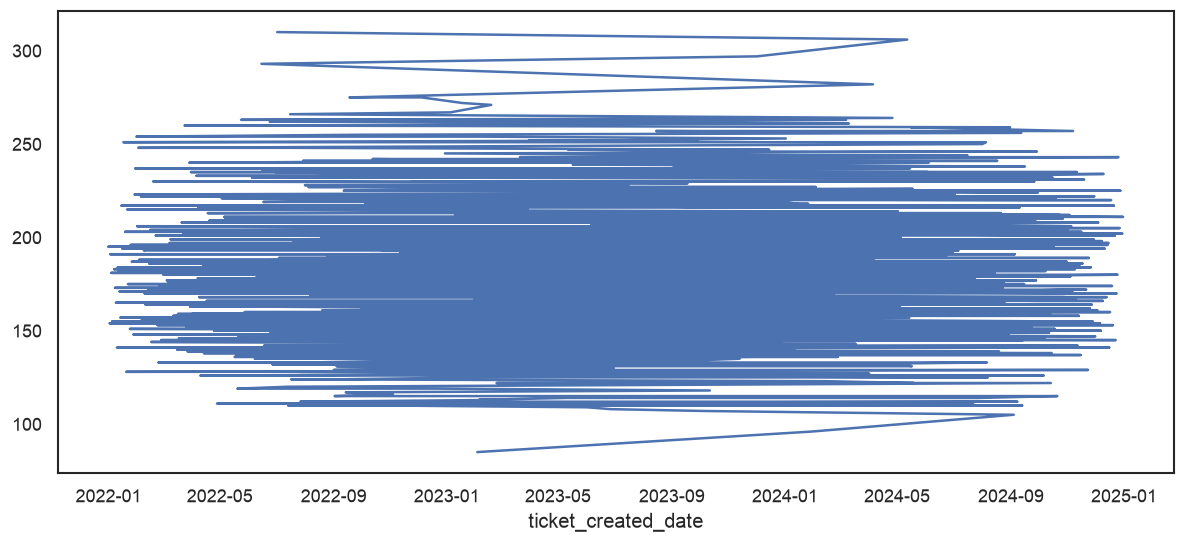

In [267]:
daily_ticket_trend.plot()

#### 4. Network KPI Engineering

In [268]:
#1. Average Network Latency
avg_latency = (
    network['latency'].mean()
)
print(f'The average network latency is {avg_latency.round(2)}ms.')

The average network latency is 97.27ms.


In [269]:
#2. Average Download Speed
avg_download_speed = (
    network['download_speed'].mean()
)
print(f'The average download speed is {avg_download_speed.round(2)}ms.')

The average download speed is 51.88ms.


In [270]:
#3. Average Upload Speed
avg_upload_speed = (
    network['upload_speed'].mean()
)
print(f'The average upload speed is {avg_upload_speed.round(2)}ms.')

The average upload speed is 25.99ms.


In [271]:
#4. Network Congestion Rate
congestion_rate = (network['congestion'].mean() * 100)
print(f'The percentage of congestion rate is {congestion_rate.round(2)}%.')

The percentage of congestion rate is 5.63%.


In [272]:
#5. High Latency Rate 
high_latency_rate = (
    network['high_latency_flag'].mean()
    * 100
)
print(f'The percentage of high latency is {high_latency_rate.round(2)}%.')

The percentage of high latency is 4.88%.


In [273]:
#6. Average Stability Score
avg_stability_score = (
    network['stability_score'].mean()
)
print(f'The average stability score is {avg_stability_score.round(2)}.')

The average stability score is 64.23.


In [274]:
#7. High Outage Risk Rate
outage_risk_rate = (
    network['high_outage_risk'].mean()
    * 100 
)
print(f'The percentage of high outage risk is {outage_risk_rate.round(2)}%.')

The percentage of high outage risk is 5.02%.


In [275]:
#8. Network Load Distribution
network_load_dist = (
    network['network_load']
    .value_counts(normalize=True)
    * 100
)
print(network_load_dist.round(2))

network_load
High        29.71
Medium      28.02
Low         21.28
Critical    21.00
Name: proportion, dtype: float64


<Axes: >

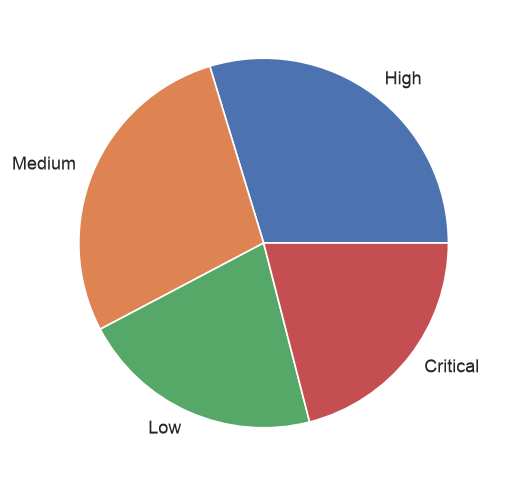

In [276]:
network_load_dist.plot(kind='pie', color= bar_colors_extended)

In [277]:
#9. Signal Quality Distribution
signal_quality_dist = (
    network['signal_quality']
    .value_counts(normalize=True)
    * 100
)
print(signal_quality_dist.round(2))

signal_quality
Average      29.24
Good         28.57
Poor         21.36
Excellent    20.83
Name: proportion, dtype: float64


<Axes: >

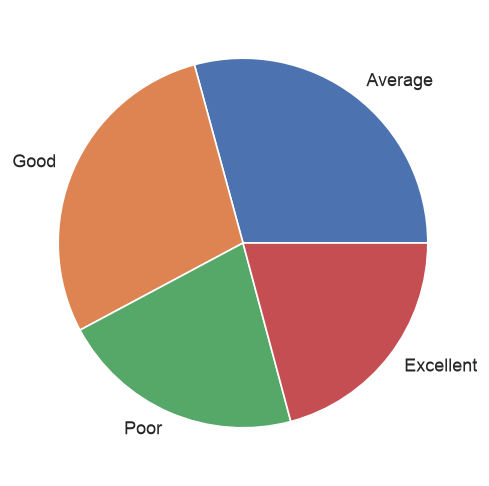

In [278]:
signal_quality_dist.plot(kind='pie', color= bar_colors_extended)

In [279]:
#10. Performance by Region
regional_network_performance = (
    network.groupby('region')['download_speed']
    .mean()
    .sort_values(ascending=False)
)
print(regional_network_performance.round(2))

region
Lagos            84.50
Abuja            66.23
Port Harcourt    44.91
Ibadan           37.05
Kano             29.21
Name: download_speed, dtype: float64


<Axes: xlabel='region'>

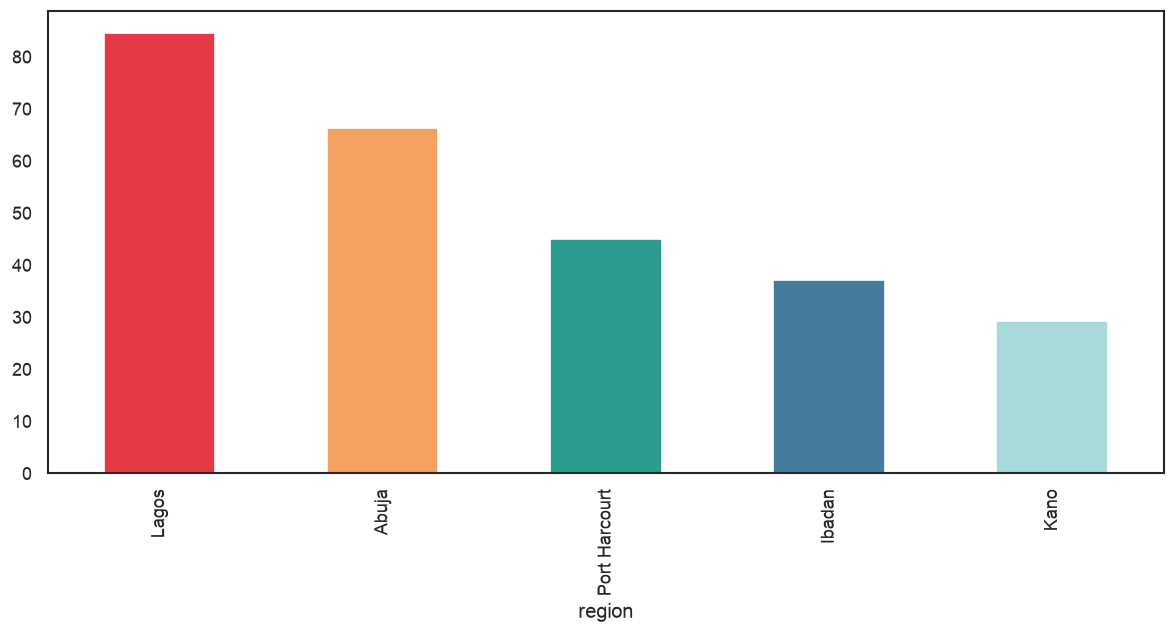

In [280]:
regional_network_performance.plot(kind='bar', color=bar_colors_extended)

In [281]:
#11. Peak Period Analysis to Identify Traffic Pressure Windows
peak_period_performance = (
    network.groupby('peak_period')['latency']
    .mean()
)
print(peak_period_performance.round(2))

peak_period
Normal    97.37
Peak      97.16
Name: latency, dtype: float64


<Axes: xlabel='peak_period'>

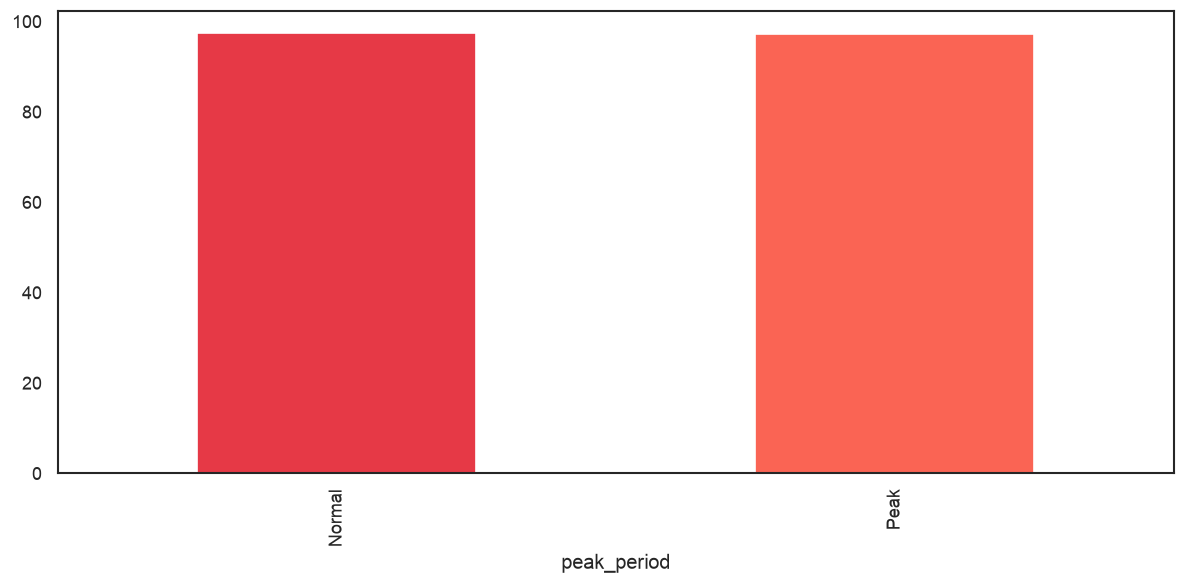

In [282]:
peak_period_performance.plot(kind='bar', color= bar_colors)

In [283]:
#12. Average Failed Requests
avg_failed_requests = (
    network['failed_requests'].mean()
)
print(f'The average failed requests recorded is {avg_failed_requests.round(2)}.')

The average failed requests recorded is 4.78.


In [284]:
network.columns

Index(['session_id', 'timestamp', 'tower_id', 'region', 'users_connected',
       'weather', 'congestion', 'network_type', 'signal_strength',
       'download_speed', 'upload_speed', 'latency', 'failed_requests',
       'network_load', 'high_latency_flag', 'stability_score',
       'poor_network_experience', 'download_performance', 'signal_quality',
       'hour', 'day_of_week', 'peak_period', 'outage_risk_score',
       'high_outage_risk', 'outage_flag'],
      dtype='str')

In [285]:
network['outage_risk_score'].describe()

count    3605.000000
mean       35.768313
std        20.231137
min         0.000000
25%        20.000000
50%        32.270000
75%        50.920000
max        99.870000
Name: outage_risk_score, dtype: float64

In [286]:
#13. Outage Analysis
outage_rate = (network['outage_risk_score'].mean())
print(f'The outage rate is {outage_rate.round(2)}%.')

The outage rate is 35.77%.


In [287]:
#14. Tower Performance Analysis
tower_performance = (
    network.groupby('tower_id')['download_speed']
    .mean()
    .sort_values()
)
print(tower_performance.round(2))

tower_id
1    50.75
3    51.25
5    51.80
2    52.32
4    53.28
Name: download_speed, dtype: float64


<Axes: xlabel='tower_id'>

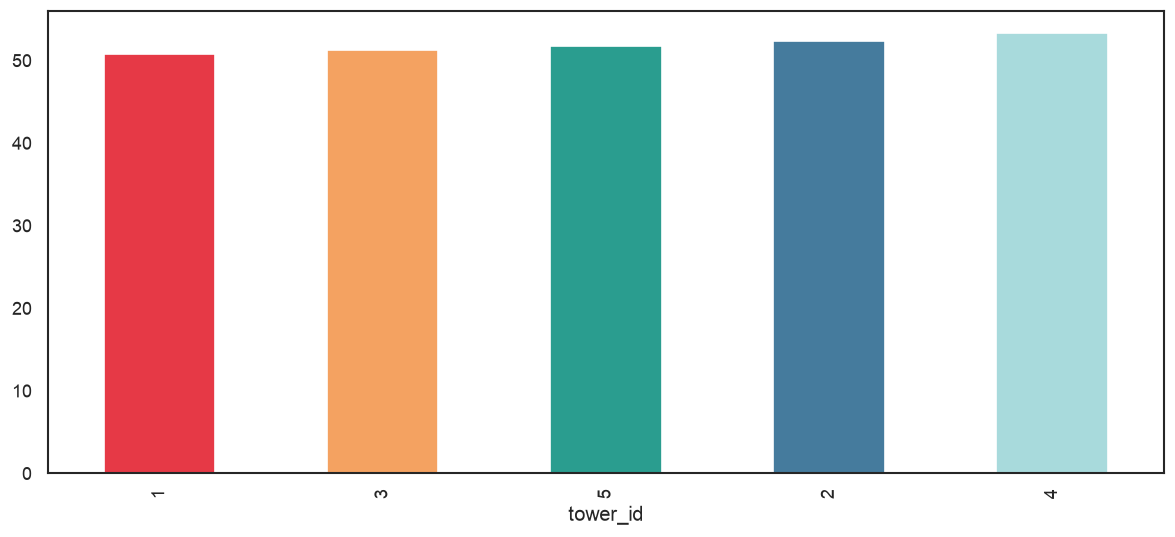

In [288]:
tower_performance.plot(kind='bar', color= bar_colors_extended)

In [289]:
#15. Daily Network Performance Trend
daily_network_trend = (
    network.groupby(
        network['timestamp'].dt.date)
    ['latency'].mean()
)
print(daily_network_trend)

timestamp
2025-01-01     96.083333
2025-01-02     92.325000
2025-01-03    107.833333
2025-01-04     88.025000
2025-01-05     94.000000
2025-01-06    106.200000
2025-01-07     92.675000
2025-01-08     95.600000
2025-01-09     86.091667
2025-01-10     98.216667
2025-01-11     98.500000
2025-01-12     93.550000
2025-01-13    102.016667
2025-01-14     95.425000
2025-01-15    101.575000
2025-01-16    104.441667
2025-01-17    100.925000
2025-01-18     89.375000
2025-01-19    106.516667
2025-01-20    103.600000
2025-01-21     98.891667
2025-01-22     99.316667
2025-01-23     90.825000
2025-01-24     92.600000
2025-01-25     98.925000
2025-01-26     92.433333
2025-01-27     88.700000
2025-01-28    100.158333
2025-01-29    102.250000
2025-01-30    100.350000
2025-01-31    116.400000
Name: latency, dtype: float64


<Axes: xlabel='timestamp'>

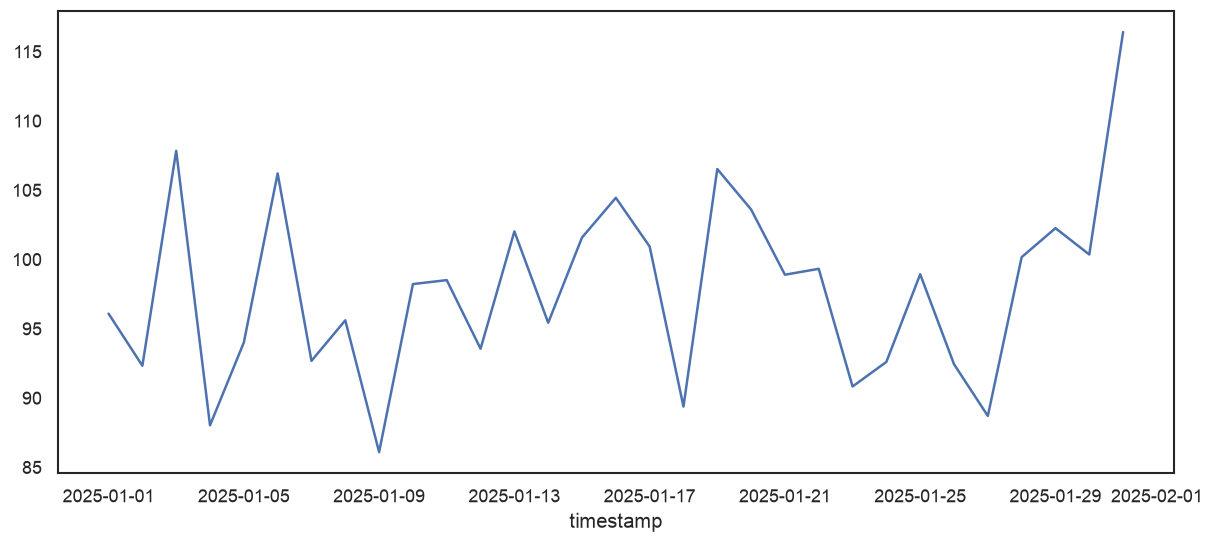

In [290]:
daily_network_trend.plot()

## Cross Dataset Analysis

#### Customer-Transaction Cross Analysis

In [291]:
## Create a dupllicate table
customer_txn_sum = (
    transactions
    .groupby('customer_id')
    .agg({'amount': 'sum', 'transaction_id': 'count'})
    .reset_index()
)

## Rename Columns
customer_txn_sum.columns = ['customer_id', 'total_transaction_amount', 'transaction_count'] 

## Merge table using left join merger
customer_txn_analysis = customer.merge(customer_txn_sum, on='customer_id', how= 'left') 

customer_txn_analysis

,customer_id,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,totalcharges,churn,tenure_group,revenue_segment,high_churn_risk,clv_segment,digital_dependency_score,predicted_clv,total_transaction_amount,transaction_count
0,Cust_00001,Female,Non-Senior,Yes,No,1,No,No,DSL,No,...,35820.0,0.0,New,Low,1,Low CLV,1,134981.41,19696496.52,154
1,Cust_00002,Male,Non-Senior,No,No,34,Yes,No,DSL,Yes,...,2267400.0,0.0,Established,Medium,0,High CLV,2,257527.35,20429499.05,145
2,Cust_00003,Male,Non-Senior,No,No,2,Yes,No,DSL,Yes,...,129780.0,1.0,New,Medium,1,Low CLV,2,243509.18,21386927.50,119
3,Cust_00004,Male,Non-Senior,No,No,45,No,No,DSL,Yes,...,2208900.0,0.0,Established,Medium,0,High CLV,3,191280.19,35829414.42,159
4,Cust_00005,Female,Non-Senior,No,No,2,Yes,No,Fiber optic,No,...,181980.0,1.0,New,High,1,Low CLV,0,319704.72,26018726.28,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Cust_07039,Male,Non-Senior,Yes,Yes,24,Yes,Yes,DSL,Yes,...,2388600.0,0.0,Growing,High,0,High CLV,5,383464.78,17319529.40,130
7039,Cust_07040,Female,Non-Senior,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,8835480.0,0.0,Loyal,VIP,0,Elite CLV,4,466669.41,23595307.76,150
7040,Cust_07041,Female,Non-Senior,Yes,Yes,11,No,No,DSL,Yes,...,415740.0,0.0,New,Low,1,Low CLV,1,133850.91,19047431.86,116
7041,Cust_07042,Male,Senior,Yes,No,4,Yes,Yes,Fiber optic,No,...,367920.0,1.0,New,High,1,Low CLV,0,336436.08,22606654.41,128


In [292]:
## revenue_segment_profile.plot(kind='bar', color= bar_colors)
revenue_segment_profile = (
    customer_txn_analysis.groupby('revenue_segment')
    ['total_transaction_amount'].mean()
)
revenue_segment_profile


revenue_segment
High      2.228907e+07
Low       2.224536e+07
Medium    2.230427e+07
VIP       2.230686e+07
Name: total_transaction_amount, dtype: float64

<Axes: xlabel='revenue_segment'>

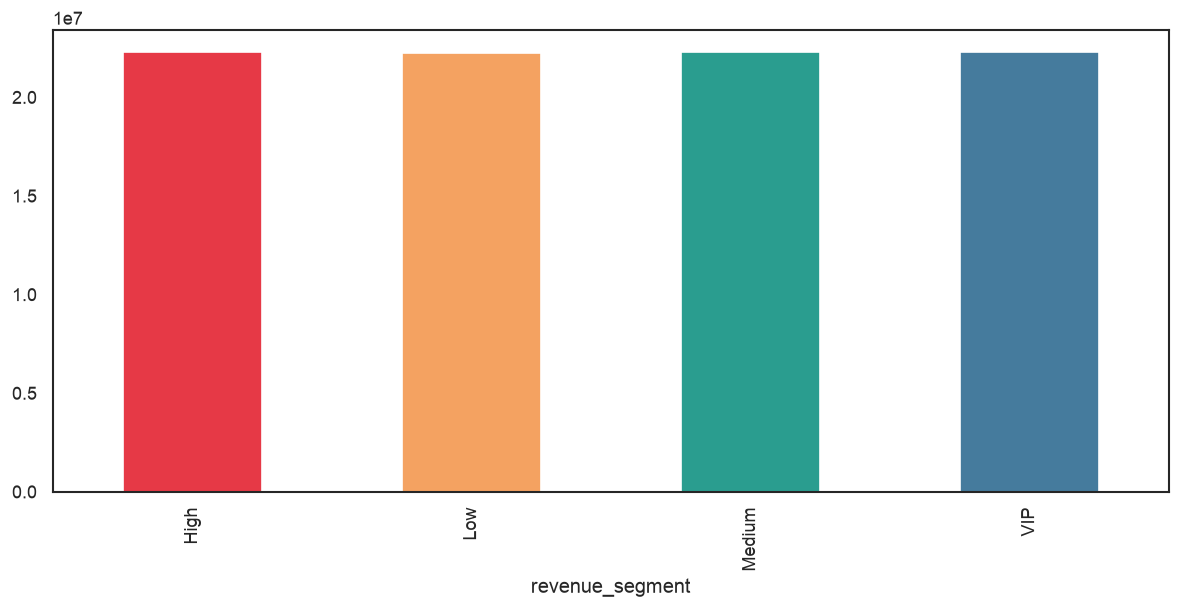

In [293]:
revenue_segment_profile.plot(kind='bar', color= bar_colors_extended)

In [294]:
## tenure vs transaction activity
tenure_transaction = (
    customer_txn_analysis.groupby('tenure_group')
    ['transaction_count'].mean()
)
tenure_transaction

tenure_group
New            141.801006
Growing        142.491211
Established    141.974906
Loyal          141.940152
Name: transaction_count, dtype: float64

<Axes: xlabel='tenure_group'>

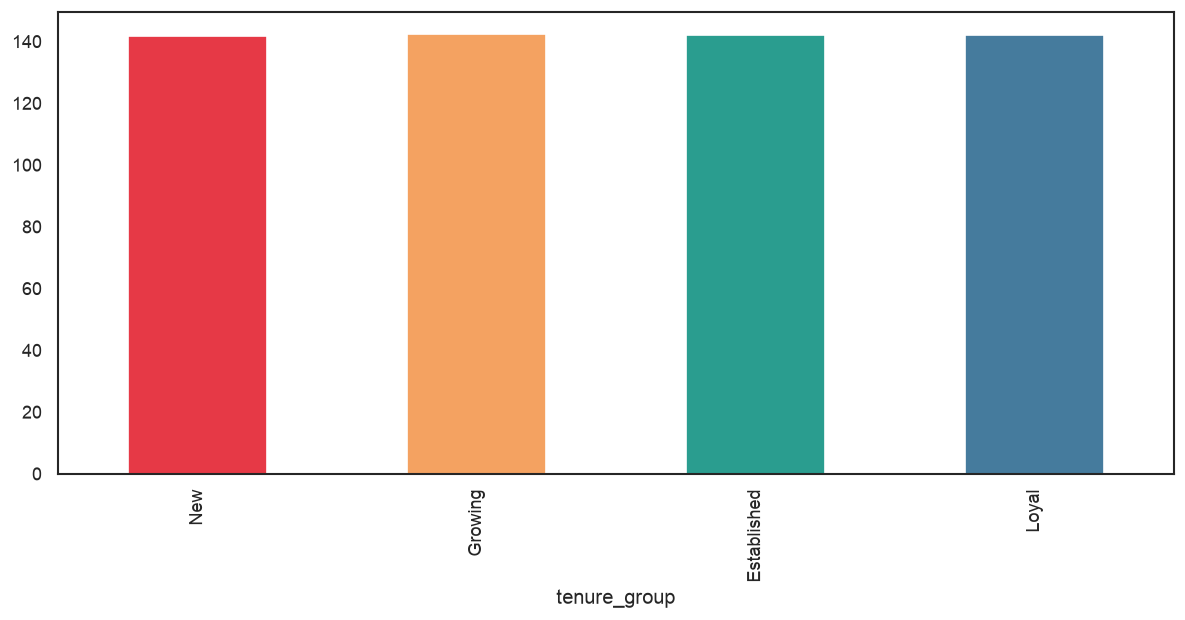

In [295]:
tenure_transaction.plot(kind='bar', color= bar_colors_extended)

In [296]:
## churn vs spending 
churn_by_spending = (
    customer_txn_analysis.groupby('churn')
    ['total_transaction_amount'].mean()
)
churn_by_spending

churn
0.0    2.228439e+07
1.0    2.228572e+07
Name: total_transaction_amount, dtype: float64

In [297]:
## payment method vs transaction behavior
payment_transaction_behaviour = (
    customer_txn_analysis.groupby(
        'paymentmethod'
    )[
        'total_transaction_amount'
    ].mean()
)
payment_transaction_behaviour

paymentmethod
Bank transfer (automatic)    2.240674e+07
Credit card (automatic)      2.240757e+07
Manual                       2.219037e+07
Name: total_transaction_amount, dtype: float64

#### Customer-Support Cross Analysis

In [298]:
## Create a dupllicate table
customer_support_summary = (
    customer_support.groupby('customer_id')
    .agg({'ticket_id': 'count', 'resolution_time_hours': 'mean'})
    .reset_index()
)

## Rename Columns
customer_support_summary.columns = ([
    'customer_id',
    'ticket_count',
    'avg_resolution_time',
])

## Merge table using left join merger
customer_support_analysis = (
    customer.merge(customer_support_summary, on='customer_id', how='left')
)

customer_support_analysis

,customer_id,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,totalcharges,churn,tenure_group,revenue_segment,high_churn_risk,clv_segment,digital_dependency_score,predicted_clv,ticket_count,avg_resolution_time
0,Cust_00001,Female,Non-Senior,Yes,No,1,No,No,DSL,No,...,35820.0,0.0,New,Low,1,Low CLV,1,134981.41,38.0,29.231579
1,Cust_00002,Male,Non-Senior,No,No,34,Yes,No,DSL,Yes,...,2267400.0,0.0,Established,Medium,0,High CLV,2,257527.35,24.0,94.800000
2,Cust_00003,Male,Non-Senior,No,No,2,Yes,No,DSL,Yes,...,129780.0,1.0,New,Medium,1,Low CLV,2,243509.18,29.0,107.682759
3,Cust_00004,Male,Non-Senior,No,No,45,No,No,DSL,Yes,...,2208900.0,0.0,Established,Medium,0,High CLV,3,191280.19,34.0,48.582353
4,Cust_00005,Female,Non-Senior,No,No,2,Yes,No,Fiber optic,No,...,181980.0,1.0,New,High,1,Low CLV,0,319704.72,35.0,77.368571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Cust_07039,Male,Non-Senior,Yes,Yes,24,Yes,Yes,DSL,Yes,...,2388600.0,0.0,Growing,High,0,High CLV,5,383464.78,21.0,109.323810
7039,Cust_07040,Female,Non-Senior,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,8835480.0,0.0,Loyal,VIP,0,Elite CLV,4,466669.41,28.0,104.396429
7040,Cust_07041,Female,Non-Senior,Yes,Yes,11,No,No,DSL,Yes,...,415740.0,0.0,New,Low,1,Low CLV,1,133850.91,22.0,116.545455
7041,Cust_07042,Male,Senior,Yes,No,4,Yes,Yes,Fiber optic,No,...,367920.0,1.0,New,High,1,Low CLV,0,336436.08,39.0,146.474359


In [299]:
## churn vs support pressure
churn_by_support = (
    customer_support_analysis.groupby('churn')
    ['ticket_count'].mean()
)
churn_by_support

churn
0.0    28.337974
1.0    28.605996
Name: ticket_count, dtype: float64

In [300]:
## tenure vs support burden
tenure_by_support = (
    customer_support_analysis.groupby('tenure_group')
    ['ticket_count'].mean()
)
tenure_by_support.round(2)

tenure_group
New            28.18
Growing        28.89
Established    28.51
Loyal          28.34
Name: ticket_count, dtype: float64

In [301]:
## contract type vs ticket volume
contract_by_ticket = (
    customer_support_analysis.groupby('contract')
    ['ticket_count'].mean()
)
contract_by_ticket.round(2)

contract
Monthly     28.16
One year    28.61
Two year    28.80
Name: ticket_count, dtype: float64

In [302]:
## Churn Risk By Average Resolution Time
churn_avg_resolution = (
    customer_support_analysis.groupby('high_churn_risk')
    ['avg_resolution_time'].mean()
)
churn_avg_resolution

high_churn_risk
0    92.853755
1    93.444083
Name: avg_resolution_time, dtype: float64

#### Transaction-Fraud Cross Analysis

In [303]:
## Create a dupllicate table
fraud_summary = (
    fraud_log.groupby('customer_id')
    .agg(
        {'is_fraud': 'sum',
         'composite_risk': 'mean'}
    ).reset_index()
)

## Rename Columns
fraud_summary.columns = [
    'customer_id',
    'fraud_count',
    'avg_risk_score'
]

## Merge table using left join merger
customer_fraud_analysis = (
    customer_support_analysis.merge(
        fraud_summary,
        on= 'customer_id',
        how='left'
    )
)
customer_fraud_analysis                                   

,customer_id,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,tenure_group,revenue_segment,high_churn_risk,clv_segment,digital_dependency_score,predicted_clv,ticket_count,avg_resolution_time,fraud_count,avg_risk_score
0,Cust_00001,Female,Non-Senior,Yes,No,1,No,No,DSL,No,...,New,Low,1,Low CLV,1,134981.41,38.0,29.231579,1.0,0.157400
1,Cust_00002,Male,Non-Senior,No,No,34,Yes,No,DSL,Yes,...,Established,Medium,0,High CLV,2,257527.35,24.0,94.800000,0.0,0.154585
2,Cust_00003,Male,Non-Senior,No,No,2,Yes,No,DSL,Yes,...,New,Medium,1,Low CLV,2,243509.18,29.0,107.682759,0.0,0.158899
3,Cust_00004,Male,Non-Senior,No,No,45,No,No,DSL,Yes,...,Established,Medium,0,High CLV,3,191280.19,34.0,48.582353,0.0,0.163559
4,Cust_00005,Female,Non-Senior,No,No,2,Yes,No,Fiber optic,No,...,New,High,1,Low CLV,0,319704.72,35.0,77.368571,0.0,0.155420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Cust_07039,Male,Non-Senior,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Growing,High,0,High CLV,5,383464.78,21.0,109.323810,1.0,0.139719
7039,Cust_07040,Female,Non-Senior,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Loyal,VIP,0,Elite CLV,4,466669.41,28.0,104.396429,0.0,0.147208
7040,Cust_07041,Female,Non-Senior,Yes,Yes,11,No,No,DSL,Yes,...,New,Low,1,Low CLV,1,133850.91,22.0,116.545455,1.0,0.158292
7041,Cust_07042,Male,Senior,Yes,No,4,Yes,Yes,Fiber optic,No,...,New,High,1,Low CLV,0,336436.08,39.0,146.474359,0.0,0.147896


In [304]:
## High Spending vs Fraud Risk
high_spending_exposure = (
    customer_fraud_analysis.groupby('clv_segment')
    ['fraud_count'].mean()
    * 100
)
high_spending_exposure.round(2)

clv_segment
Elite CLV     43.33
High CLV      42.95
Low CLV       41.51
Medium CLV    42.59
Name: fraud_count, dtype: float64

In [305]:
## Revenue Segment vs Fraud Risk
revenue_by_fraud = (
    customer_fraud_analysis.groupby('revenue_segment')
    ['fraud_count'].mean()
    * 100
)
revenue_by_fraud.round(2)

revenue_segment
High      45.16
Low       42.53
Medium    38.24
VIP       42.23
Name: fraud_count, dtype: float64

In [306]:
## Revenue Segment vs Fraud Risk
revenue_by_fraud = (
    customer_fraud_analysis.groupby('revenue_segment')
    ['avg_risk_score'].mean()
)
revenue_by_fraud.round(2)

revenue_segment
High      0.15
Low       0.15
Medium    0.15
VIP       0.15
Name: avg_risk_score, dtype: float64

In [307]:
## High Churn Risk vs High Fraud Risk
churn_fraud_risk = (
    customer_fraud_analysis.groupby('high_churn_risk')
    ['avg_risk_score'].mean()
)
churn_fraud_risk.round(2)

high_churn_risk
0    0.15
1    0.15
Name: avg_risk_score, dtype: float64

In [308]:
churn_fraud_risk = (
    customer_fraud_analysis.groupby('high_churn_risk')
    ['fraud_count'].mean()
    * 100
)
churn_fraud_risk.round(1)

high_churn_risk
0    42.6
1    42.7
Name: fraud_count, dtype: float64

#### Network-Customer Support Cross Analysis

In [309]:
## Change values to float
network['outage_flag'] = np.where(
    network['outage_flag'] == 'Yes',
    1,
    0
)

In [310]:
## Create a dupllicate table for network
network['outage_flag'] = network['outage_flag'].astype(float)
network_region_summary = (
    network.groupby('region')
    .agg({
        'latency':'mean',
        'download_speed':'mean',
        'failed_requests':'mean',
        'outage_flag':'mean',
        'congestion':'mean'
    })
)

In [311]:
## Rename columns
network_region_summary.columns = [
    'avg_latency',
    'avg_download_speed',
    'avg_failed_requests',
    'outage_risk_rate',
    'avg_congestion'
]
network_region_summary.round(2)

,avg_latency,avg_download_speed,avg_failed_requests,outage_risk_rate,avg_congestion
region,,,,,
Abuja,58.81,66.23,3.02,0.0,0.06
Ibadan,129.13,37.05,5.58,0.0,0.04
Kano,153.43,29.21,7.38,0.0,0.05
Lagos,45.81,84.50,3.08,0.0,0.07
Port Harcourt,92.45,44.91,4.58,0.0,0.06


In [312]:
## Create a dupllicate table for customer support
support_region_summary = (
    customer_support.groupby('region')
    .agg({
        'ticket_id':'count',
        'resolution_time_hours':'mean',
        'customer_satisfaction_score':'mean',
        'escalated': lambda x:
            (x == 'Yes').mean()
    })
    .reset_index()
)
support_region_summary.round(2)

,region,ticket_id,resolution_time_hours,customer_satisfaction_score,escalated
0,Abuja,39977,93.59,3.19,0.5
1,Ibadan,40295,94.91,3.18,0.5
2,Kano,40163,94.47,3.18,0.5
3,Lagos,39469,93.80,3.17,0.5
4,Port Harcourt,40096,94.92,3.18,0.5


In [313]:
## Rename Columns
support_region_summary.columns = [
    'region',
    'ticket_volume',
    'avg_resolution_time',
    'avg_satisfaction',
    'escalation_rate'
]
support_region_summary.round(2)

,region,ticket_volume,avg_resolution_time,avg_satisfaction,escalation_rate
0,Abuja,39977,93.59,3.19,0.5
1,Ibadan,40295,94.91,3.18,0.5
2,Kano,40163,94.47,3.18,0.5
3,Lagos,39469,93.80,3.17,0.5
4,Port Harcourt,40096,94.92,3.18,0.5


In [314]:
network_support_analysis = (
    network_region_summary.merge(support_region_summary, 
                                 on= 'region',
                                 how= 'inner'
                                )
)
network_support_analysis

,region,avg_latency,avg_download_speed,avg_failed_requests,outage_risk_rate,avg_congestion,ticket_volume,avg_resolution_time,avg_satisfaction,escalation_rate
0,Abuja,58.813031,66.228470,3.022663,0.0,0.059490,39977,93.589752,3.187415,0.500088
1,Ibadan,129.134890,37.051492,5.582361,0.0,0.042802,40295,94.906189,3.178370,0.499367
2,Kano,153.432000,29.209733,7.381333,0.0,0.050667,40163,94.474688,3.180848,0.504768
3,Lagos,45.807092,84.500426,3.080851,0.0,0.069504,39469,93.801599,3.167025,0.495376
4,Port Harcourt,92.451709,44.914562,4.578009,0.0,0.060921,40096,94.915887,3.181749,0.502469


In [315]:
## Latency vs Ticket Volume
latency_ticket_correlation = (
    network_support_analysis[
        ['avg_latency', 'ticket_volume']
        ]
).corr()
latency_ticket_correlation

,avg_latency,ticket_volume
avg_latency,1.0000,0.7978
ticket_volume,0.7978,1.0000


<Axes: xlabel='avg_latency', ylabel='ticket_volume'>

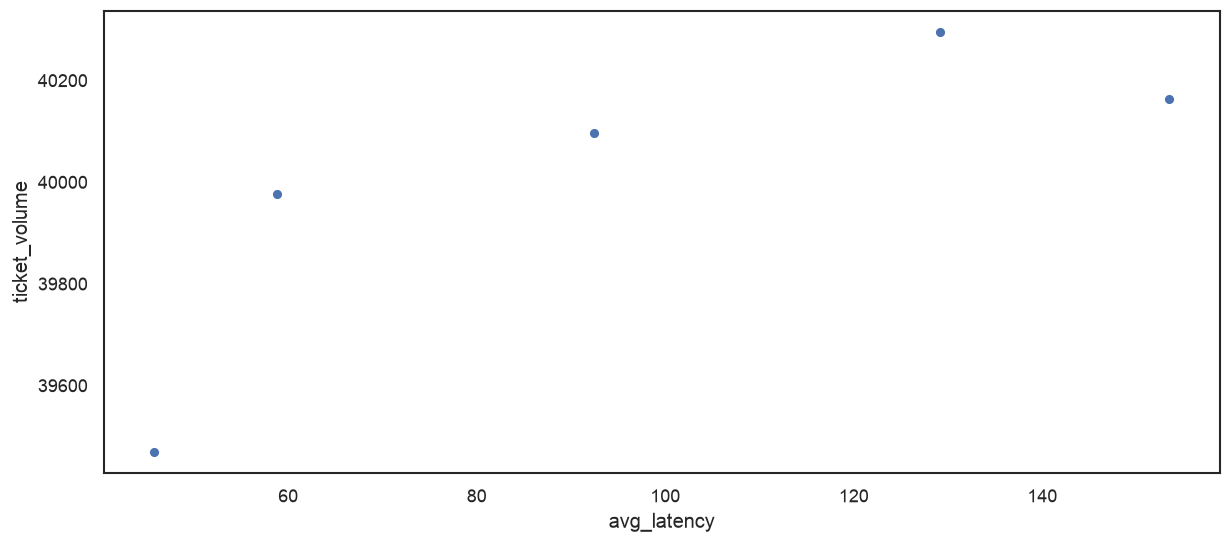

In [316]:
network_support_analysis.plot(
    x='avg_latency',
    y='ticket_volume',
    kind='scatter'
)

In [317]:
## Download Speed vs Customer Satisfaction
download_vs_satisfaction = (
    network_support_analysis[
        ['avg_download_speed', 'avg_satisfaction']
        ]
).corr()
download_vs_satisfaction

,avg_download_speed,avg_satisfaction
avg_download_speed,1.000000,-0.473098
avg_satisfaction,-0.473098,1.000000


<Axes: xlabel='avg_download_speed', ylabel='avg_satisfaction'>

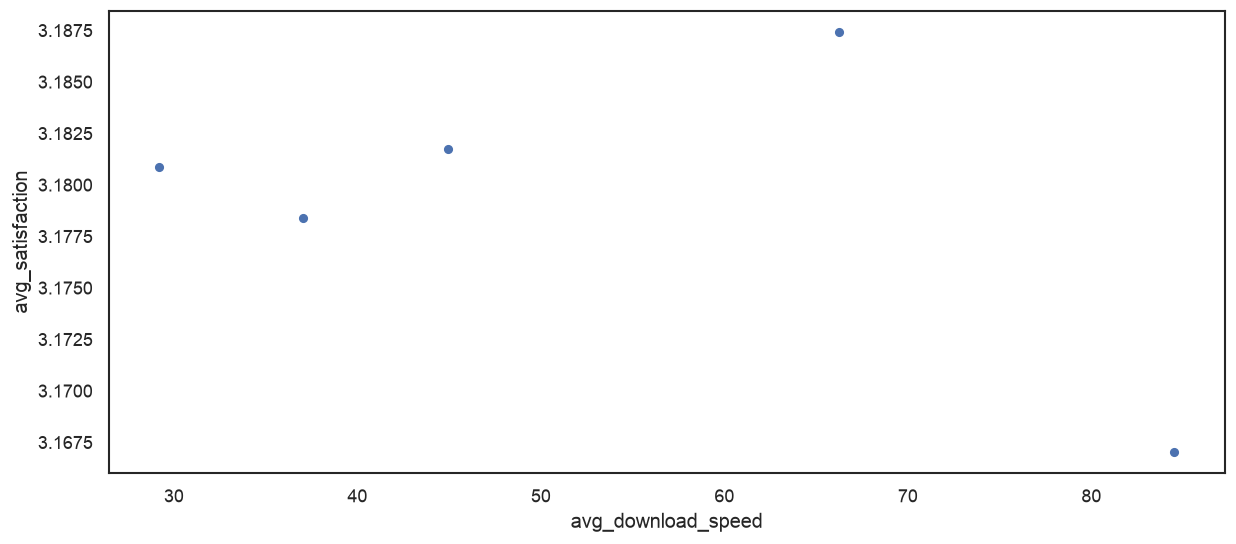

In [318]:
network_support_analysis.plot(
    x='avg_download_speed',
    y='avg_satisfaction',
    kind='scatter'
)

In [319]:
## Congestion vs Average Resolution Time
congestion_by_resolution = (
    network_support_analysis[
        ['avg_congestion', 'avg_resolution_time']
        ]
).corr()
congestion_by_resolution

,avg_congestion,avg_resolution_time
avg_congestion,1.000000,-0.603118
avg_resolution_time,-0.603118,1.000000


<Axes: xlabel='avg_congestion', ylabel='avg_resolution_time'>

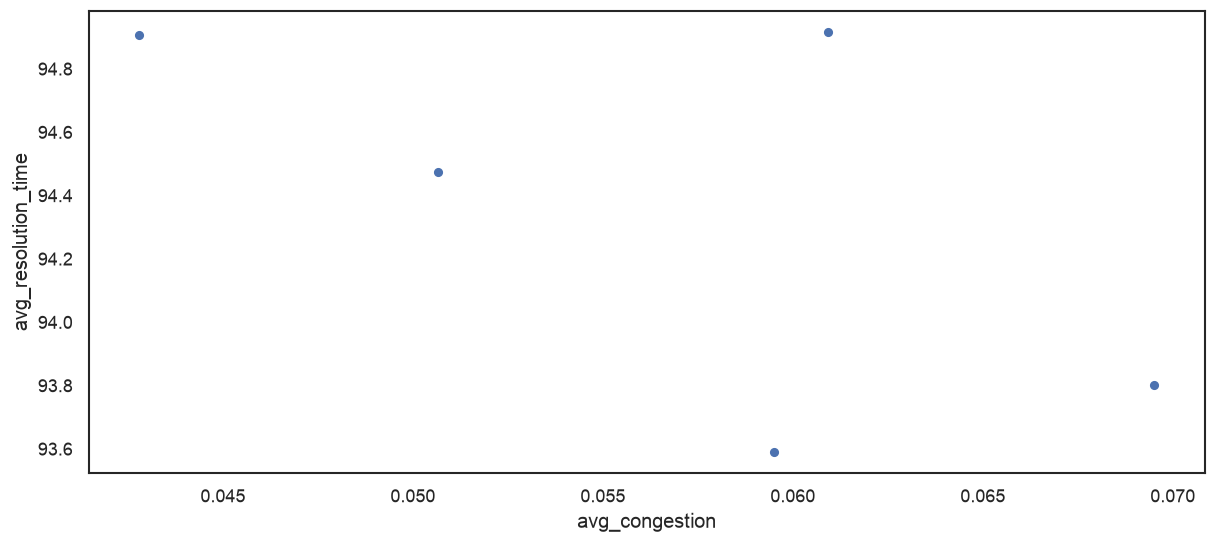

In [320]:
network_support_analysis.plot(
    x='avg_congestion',
    y='avg_resolution_time',
    kind='scatter'
)

In [321]:
## Create dataset for visualization
customer_dashboard = customer[
[
'customer_id',
'tenure',
'monthlycharges',
'totalcharges',
'contract',
'paymentmethod',
'churn',
'revenue_segment',
'high_churn_risk',
'tenure_group',
'clv_segment',
'digital_dependency_score'
]
]


In [322]:
## Convert dataset to csv
customer_dashboard.to_csv('customer_dashboard.csv', index=False)

In [323]:
transactions_dashboard = transactions[
[
    'transaction_id',
    'customer_id',
    'transaction_time',
    'amount',
    'type',
    'channel',
    'region',
    'transaction_hour',
    'is_weekend',
    'is_peak_hr',
    'night_transaction',
    'high_value_txn'
]
]

In [324]:
transactions_dashboard.to_csv('transactions_dashboard.csv', index=False)

In [325]:
customer_support_dashboard = customer_support[
    [
        'product', 
        'category', 
        'priority', 
        'status', 
        'channel', 
        'region',
        'customer_age', 
        'customer_gender', 
        'customer_tenure_months', 
        'customer_satisfaction_score', 
        'resolution_time_hours', 
        'ticket_created_date', 
        'escalated', 
        'sla_breached'
    ]
    ]

In [326]:
customer_support_dashboard.to_csv('customer_support_dashboard.csv', index=False)

In [327]:
new_fraud_log_dashboard = fraud_log[
    [
        'timestamp', 
        'transaction_hour', 
        'amount', 
        'channel', 
        'merchant_category',  
        'region', 
        'age_group',   
        'is_fraud', 
        'fraud_technique', 
        'fraud_severity', 
        'velocity_score', 
        'merchant_risk_score',
        'composite_risk'
    ]
    ]

In [328]:
new_fraud_log_dashboard.to_csv('new_fraud_log_dashboard.csv', index=False)

In [329]:
network_dash_board = network[
    [
        'timestamp', 
        'hour', 
        'day_of_week', 
        'tower_id', 
        'region', 
        'network_type', 
        'weather', 
        'users_connected', 
        'congestion', 
        'download_speed', 
        'upload_speed', 
        'latency', 
        'signal_strength',
        'failed_requests',
        'outage_risk_score'
    ]
    ]

In [330]:
network_dash_board.to_csv('network_dash_board.csv', index=False)

### Conclusion 

#### 📊 Key Findings & Business Recommendations

This analysis surfaced critical intelligence across all five operational domains of the business.
Below is a consolidated summary of findings and the strategic actions they support.

#### 1. Customer Retention Analysis 

**Finding:** The overall churn rate stands at **26.5%** (1,869 customers lost from a base of
7,043), with **27.1% of the total customer base** (1,908 customers) currently flagged as high
churn risk. Churn is structurally concentrated (not randomly distributed) in three
overlapping segments: **new customers (0–12 months tenure), monthly-contract subscribers,**
and **Low CLV customers.** Monthly contracts account for the overwhelming majority of churn
volume, churning at approximately 3× the rate of one-year contract customers.

**Insight:** The average customer tenure of **32 months** and MRR of **₦547.34M** indicate a
healthy installed base, but the 27.1% high-risk customer represents a direct revenue threat of
approximately **₦148M annual MRR** if left unaddressed.

**Recommendation:**
- Launch a targeted contract upgrade campaign for monthly subscribers in their first 12 months,
  offering incentives to shift to annual contracts.
- Introduce an early-tenure onboarding programme for New-segment customers; the data shows that
  this group churns at nearly 3× the rate of Established and Loyal customers.
- Prioritise Manual payment method customers (56.47% of base) for automatic payment conversion,
  as payment friction is a known churn accelerant.

#### 2. Transaction Performance Analysis 
**Finding:** The platform processed **113,051 transactions** worth **₦11.87B** in the observed
period, with an average transaction value of **₦105.02K.** Lagos alone accounts for the largest
share of both transaction volume (~ 60K) and total value (~ ₦6B), followed by Abuja (~ ₦4B).
The **Mobile channel** leads on volume (~ 50K transactions) while both **Mobile and IB
(Internet Banking)** lead on transaction value (~ ₦4B each). Transaction activity peaks sharply
at **10am, 1pm, and 4pm** (a clear three-window daily pattern).

**Insight:** The high-value transaction rate declined **20.9% month-over-month**, signalling
either a behavioural shift among premium customers or a product-level issue worth investigating.

**Recommendation:**
- Concentrate infrastructure and customer experience investment in Lagos and Abuja, which
  together account for the majority of platform revenue.
- Design Mobile-first product features, as it is the dominant channel by both volume and value.
- Investigate the month-over-month decline in high-value transaction rate; this may correlate
  with the elevated fraud rates seen on the Web and Mobile channels.

#### 3. Fraud Intelligence Analysis 
**Finding:** The overall fraud rate is **0.30%** across 1,000,000 transactions (3,000 confirmed
fraud cases). While the rate appears low, **315,668 transactions** are flagged as high-risk
incidents, suggesting the detection net is catching suspicious activity at scale.
**Social engineering** accounts for **1,929 of 3,000 fraud cases (64%)**, far exceeding robbery,
card theft, and other techniques combined. Geographically, **Lagos** carries the highest absolute
fraud load **(1,544 cases)**, though this reflects its transaction dominance. The **Web channel**
has the highest fraud penetration rate at **0.34%**, with Mobile close behind at **0.33%**.

**Insight:** The geographic fraud risk map confirms a high-risk corridor concentrated in Lagos
and Abuja (the same regions with the highest transaction velocity), suggesting that fraud
activity scales with platform usage density, not regional vulnerability alone.

**Recommendation:**
- Deploy social engineering-specific fraud rules (e.g., unusual beneficiary patterns, rapid
  successive transfers) as the primary detection layer, given that Card_theft and Robbery rules
  are currently being triggered more often but converting at lower fraud rates.
- Tighten velocity controls on the Web channel, which has the highest fraud penetration rate.
- Implement a region-aware risk scoring system that adjusts thresholds dynamically for Lagos
  and Abuja, where both transaction volume and fraud concentration are highest.

#### 4. Customer Support Analysis
**Finding:** With **160,013 tickets raised**, an average resolution time of **126 hours**,
a CSAT score of only **2.90/5.00**, an SLA breach rate of **41.9%**, and an escalation rate of
**42.46%**, the support operation is in critical underperformance. The most counterintuitive
finding is the SLA breach pattern: **Low-priority tickets breach SLA at 82.9%**, compared to
only 7.5% for Urgent tickets. This indicates that the team triages urgency correctly but
systematically neglects low-priority queues, which accumulate silently and erode satisfaction.
**Bug Reports (78.38%)** and **Security Concerns (70.81%)** drive the highest escalation rates.

**Insight:** The average first response time of 25.39 hours, which should be near-instant
acknowledgement, is a key satisfaction driver. Customers who wait over a day for a first
response are unlikely to rate their experience above 3/5.

**Recommendation:**
- Implement a low-priority queue flush policy — dedicating a fixed daily agent capacity to
  clearing aged low-priority tickets, which will disproportionately reduce the SLA breach rate.
- Set a first-response SLA target of ≤4 hours across all ticket priorities, since first
  response time is the single biggest lever on CSAT scores.
- Create a Bug Report fast-track workflow with direct engineering escalation, given its
  78.38% supervisor intervention rate.

#### 5. Network Performance
**Finding:** Network performance data reveals a clear and statistically significant
north–south divide. **Lagos leads all regions** with the highest download speed (83.4 Mbps),
lowest latency (30ms), and lowest outage risk (14.9%). **Kano is the worst performer**:
download speed of just 25.0 Mbps, latency of 154ms (**5× worse than Lagos**) and an
infrastructure outage risk of **74.6%**. Ibadan and Port Harcourt sit in a troubled middle tier,
with latency above 130ms and outage risk above 40%. Notably, **weather has minimal impact**
on download performance (range of only 3.3 Mbps across all conditions), suggesting that
performance degradation is infrastructure-driven, not environmental.

**Insight:** Cross-referencing network performance with customer support data, the regions with
the worst network performance (Kano, Ibadan) also carry elevated support ticket burdens which is 
consistent with the hypothesis that network degradation drives support demand.

**Recommendation:**
- Prioritise tower infrastructure investment in Kano and Ibadan as the highest-impact
  intervention for both network reliability and customer satisfaction.
- Build a network-to-churn early warning model: given the correlation between poor network
  experience and support escalation, sustained network degradation in Kano and Ibadan is a
  leading indicator of churn risk in those regions.
- Investigate whether Kano's 74.6% outage risk score is being driven by a small number of
  underperforming towers.


#### Cross-Domain Summary
- **Domain:**
Customer Retention
**Key Metric:**
26.5% churn, 27.1% high-risk
**Status:**
🔴 Critical
**Priority:**
Immediate

- **Domain:**
Fraud Intelligence
**Key Metric:**
0.30% fraud rate, 64% social engineering
**Status:**
🟡 Moderate
**Priority:**
High

- **Domain:**
Transaction Performance
**Key Metric:**
₦11.87B value, Mobile-first
**Status:**
🟢 Healthy
**Priority:**
Monitor

- **Domain:**
Customer Support
**Key Metric:**
126hr resolution, 41.9% SLA breach 
**Status:**
🔴 Critical
**Priority:**
Immediate

- **Domain:**
Network Performance
**Key Metric:**
Kano 74.6% outage risk, 5× latency gap
**Status:**
🔴 Critical
**Priority:**
High

#### What This Project Demonstrates
This project showcases a comprehensive end-to-end analytical capability across the full data analyst skill
stack which includes multi-source data integration, data quality engineering, feature engineering with business
logic, KPI design, exploratory analysis, cross-domain relational reasoning, and executive-ready
visualisation. The Tableau dashboards translate this Python-based analysis into an
interactive decision-support layer suitable for business stakeholders at any technical level.

*The complete interactive dashboards are available on Tableau Public (attached below)*

https://surl.li/itqyrd - customer retention dashboard

https://surli.cc/mrycne - financial operations and transaction performance  dashboard 

https://surl.li/egwrqm - fraud intelligence dashboard 

https://surl.li/pzfscy - customer support dashboard 

https://surl.li/jouyjf - network performance dashboard 